## Assignment 2: Neural Chef Assistant

Maryam Nazir Chaudhary (31435599)

### 1.0 Prior Dependencies

#### 1.0.1 Loading Packages

In [ ]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from bert_score import score
import pandas as pd

# Ensure required downloads
#nltk.download('punkt')
#nltk.download('wordnet')  # required for METEOR
#nltk.download('punkt_tab')

#pip install ingredient-parser-nlp
#pip install nltk bert-score


/home/mcha0106/cn78_scratch/mcha0106/miniconda3/envs/py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
## Requirements
from __future__ import unicode_literals, print_function, division
from io import open
import unicodedata
import string
import re
import random

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F

import csv
import ast
import os
import pickle

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


#### 1.0.2 Helper Functions

In [ ]:
# helper function to print time elapsed and estimated
# time remaining given the current time and progress %.

import time
import math


def asMinutes(s):
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)


def timeSince(since, percent):
    now = time.time()
    s = now - since
    es = s / (percent)
    rs = es - s
    return '%s (- %s)' % (asMinutes(s), asMinutes(rs))

In [ ]:
# helper function to plot losses

import matplotlib.pyplot as plt
plt.switch_backend('agg')
import matplotlib.ticker as ticker
import numpy as np
%matplotlib inline

def showPlot(points):
    plt.figure()
    fig, ax = plt.subplots()
    # this locator puts ticks at regular intervals
    loc = ticker.MultipleLocator(base=0.2)
    ax.yaxis.set_major_locator(loc)
    plt.plot(points)


# To save losses per model
def save_losses_to_csv(losses, filename):
    with open(filename, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['Loss'])  # header
        for loss in losses:
            writer.writerow([loss])


### 1.1 The 2 Baselines🌶️
Preprocessing retained for both baseline models and mild 1 model.


In [ ]:
# To encode each word as a one-hot vector

SOS_token = 0
EOS_token = 1


class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {"SOS": 0, "EOS": 1, "<UNK>": 2}
        self.word2count = {}
        self.index2word = {0: "SOS", 1: "EOS", 2: "<UNK>"}
        self.n_words = 3  # Count SOS and EOS and UNK

    def addSentence(self, sentence):
        for word in sentence.split(' '):
            self.addWord(word)

    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

In [ ]:
# Turn a Unicode string to plain ASCII (https://stackoverflow.com/a/518232/2809427)
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

# Lowercase, trim, and remove non-letter characters
def normalizeString(s):
    s = unicodeToAscii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z.!?]+", r" ", s)
    return s

# To process each list per row
def normalizeListString(list_str):
    try:
        parsed = ast.literal_eval(list_str)
        return normalizeString(' '.join(parsed))
    except:
        return normalizeString(list_str)

In [ ]:
def readLangs_from_csv(csv_path):
    print("Reading CSV lines...")
    pairs = []

    with open(csv_path, encoding='utf-8') as csvfile:
        reader = csv.DictReader(csvfile)
        for row in reader:
            # Join ingredients and recipe steps into strings
            ing = normalizeListString(row["Ingredients"])
            rec = normalizeListString(row["Recipe"])
            pairs.append([ing, rec])

    input_lang = Lang("ingredients")
    output_lang = Lang("recipe")

    return input_lang, output_lang, pairs


In [ ]:
# Full process for preparing the data using the above functions

def prepareData_from_csv(csv_path):
    input_lang, output_lang, pairs = readLangs_from_csv(csv_path)
    print(f"Read {len(pairs)} sentence pairs")
    print("Counting words...")
    for pair in pairs:
        input_lang.addSentence(pair[0])
        output_lang.addSentence(pair[1])
    print("Counted words:")
    print(input_lang.name, input_lang.n_words)
    print(output_lang.name, output_lang.n_words)
    return input_lang, output_lang, pairs

In [ ]:
# Processing training data

input_lang, output_lang, pairs = prepareData_from_csv('train.csv')
print(random.choice(pairs))

Reading CSV lines...
Read 162899 sentence pairs
Counting words...
Counted words:
ingredients 8860
recipe 12784
[' oz . can eagle brand c . cold milk serving size instant vanilla pie filling mix c . whipping cream vanilla wafers bananas sliced and dipped in lemon juice', 'combine in large bowl the condensed milk and wafers . add pudding mix . beat well . chill minutes . fold in whipped cream . spoon cup pudding mixture into quart glass serving bowl . top with each of the wafers bananas and pudding . repeat layering twice . end with pudding . chill . garnish . refrigerate .']


In [ ]:
# Processing training data

val_input_lang, val_output_lang, val_pairs = prepareData_from_csv('dev.csv')
print(random.choice(val_pairs))

Reading CSV lines...
Read 1065 sentence pairs
Counting words...
Counted words:
ingredients 1469
recipe 2095
[' c . fresh basil leaves or parsley or spinach washed and drained garlic cloves c . walnuts c . parmesan cheese c . olive oil', 'combine fresh leaves and garlic in a food processor . blend into a fine paste scraping sides often . add walnuts and cheese . process until smooth but slightly grainy . pour olive oil through feed tube slowly with machine running . mix until smooth . makes about cups . use within one month . store in refrigerator .']


In [ ]:
# Processing test data

test_input_lang, test_output_lang, test_pairs = prepareData_from_csv('test.csv')
print(random.choice(test_pairs))

Reading CSV lines...
Read 1081 sentence pairs
Counting words...
Counted words:
ingredients 1406
recipe 2053
[' inch pie shell cooked pt . vanilla ice cream c . canned pumpkin c . sugar tsp . each nutmeg ginger and cinnamon tsp . salt c . whipping cream', 'line pie shell with ice cream . make layer inch thick . place in freezer . blend together the pumpkin sugar nutmeg ginger cinnamon and salt . whip cream until stiff fold into pumpkin mixture . spoon over ice cream in pie shell . return to freezer for at least hours . let stand at room temperature minutes before cutting .']


In [ ]:
# Processing qualitative comparison data

qual_input_lang, qual_output_lang, qual_pairs = prepareData_from_csv('qual.csv')
print(random.choice(qual_pairs))

Reading CSV lines...
Read 2 sentence pairs
Counting words...
Counted words:
ingredients 29
recipe 5
['sugar lemon juice water orange juice strawberries icecream', 'na .']


#### 1.1.1 Sequence-to-Sequence model without attention
Largely references Week 7 Tutorial Part 1 - Seq2Seq model

In [ ]:
# An encoder to read an input sequence and outputs a single context vector,
# which captures the meaning of the entire vector sequence

class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(input_size, hidden_size)
        '''
        GRU is a gated RNN variant that captures long-term dependencies more effectively with fewer parameters. GRU has the same output shape as a standard RNN when configured identically.
        '''
        self.gru = nn.GRU(hidden_size, hidden_size)

    def forward(self, input, hidden):
        embedded = self.embedding(input).view(1, 1, -1)
        output = embedded
        output, hidden = self.gru(output, hidden)
        return output, hidden

    def initHidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)

In [ ]:
# A decoder to read the context vector and outputs a sequence of words to create the recipe

class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(DecoderRNN, self).__init__()
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):
        output = self.embedding(input).view(1, 1, -1)
        output = F.relu(output)
        output, hidden = self.gru(output, hidden)
        output = self.softmax(self.out(output[0]))
        return output, hidden

    def initHidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)


In [ ]:
# Preparing the training data to create input and target tensors

def indexesFromSentence(lang, sentence):
    return [lang.word2index.get(word, input_lang.word2index['<UNK>']) for word in sentence.split(' ')]


def tensorFromSentence(lang, sentence):
    indexes = indexesFromSentence(lang, sentence)
    indexes.append(EOS_token) # appending the EOS token
    return torch.tensor(indexes, dtype=torch.long, device=device).view(-1, 1)


def tensorsFromPair(pair):
    input_tensor = tensorFromSentence(input_lang, pair[0])
    target_tensor = tensorFromSentence(output_lang, pair[1])
    return (input_tensor, target_tensor)

In [ ]:
# To train the model

teacher_forcing_ratio = 0.5 # to use the real target outputs (not decoder’s guess) as each next input


def train(input_tensor, target_tensor, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion):
    encoder_hidden = encoder.initHidden()

    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()

    input_length = input_tensor.size(0)
    target_length = target_tensor.size(0)

    encoder_outputs = torch.zeros(input_length, encoder.hidden_size, device=device)

    loss = 0

    # run the input sentence through the encoder and keep track of every output and the latest hidden state.
    for ei in range(input_length):
        encoder_output, encoder_hidden = encoder(
            input_tensor[ei], encoder_hidden)
        encoder_outputs[ei] = encoder_output[0, 0]

    # decoder is given the <SOS> token & the last encoder hidden state as its first input & first hidden state
    decoder_input = torch.tensor([[SOS_token]], device=device)

    decoder_hidden = encoder_hidden

    use_teacher_forcing = True if random.random() < teacher_forcing_ratio else False

    if use_teacher_forcing:
        # Teacher forcing: Feed the target as the next input
        for di in range(target_length):
            decoder_output, decoder_hidden = decoder(
                decoder_input, decoder_hidden)
            loss += criterion(decoder_output, target_tensor[di])
            decoder_input = target_tensor[di]  # Teacher forcing

    else:
        # Without teacher forcing: use its own predictions as the next input
        for di in range(target_length):
            decoder_output, decoder_hidden = decoder(
                decoder_input, decoder_hidden)
            topv, topi = decoder_output.topk(1)
            decoder_input = topi.squeeze().detach()  # detach from history as input

            loss += criterion(decoder_output, target_tensor[di])
            if decoder_input.item() == EOS_token:
                break

    loss.backward()

    encoder_optimizer.step()
    decoder_optimizer.step()

    return loss.item() / target_length


In [ ]:
# To call train iteratively and periodically print the progress
# (% of examples, time so far, estimated time) and average loss.

def trainIters(encoder, decoder, n_iters, print_every=1000, plot_every=100, learning_rate=0.01):
    start = time.time()
    plot_losses = []
    print_loss_total = 0  # Reset every print_every
    plot_loss_total = 0  # Reset every plot_every

    encoder_optimizer = optim.SGD(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.SGD(decoder.parameters(), lr=learning_rate)
    training_pairs = [tensorsFromPair(random.choice(pairs))
                      for i in range(n_iters)]
    criterion = nn.NLLLoss()

    for iter in range(1, n_iters + 1):
        training_pair = training_pairs[iter - 1]
        input_tensor = training_pair[0]
        target_tensor = training_pair[1]

        loss = train(input_tensor, target_tensor, encoder,
                     decoder, encoder_optimizer, decoder_optimizer, criterion)
        print_loss_total += loss
        plot_loss_total += loss

        if iter % print_every == 0:
            print_loss_avg = print_loss_total / print_every
            print_loss_total = 0
            print('%s (%d %d%%) %.4f' % (timeSince(start, iter / n_iters),
                                         iter, iter / n_iters * 100, print_loss_avg))

        if iter % plot_every == 0:
            plot_loss_avg = plot_loss_total / plot_every
            plot_losses.append(plot_loss_avg)
            plot_loss_total = 0

    showPlot(plot_losses)

    save_losses_to_csv(plot_losses, 'losses_base1.csv')


4m 31s (- 63m 23s) (5000 6%) 13.9486
8m 54s (- 57m 52s) (10000 13%) 16.5477
13m 12s (- 52m 50s) (15000 20%) 16.0075
17m 33s (- 48m 16s) (20000 26%) 16.3161
21m 49s (- 43m 39s) (25000 33%) 14.9019
26m 9s (- 39m 14s) (30000 40%) 14.4352
30m 29s (- 34m 50s) (35000 46%) 14.3679
34m 49s (- 30m 28s) (40000 53%) 14.6335
39m 8s (- 26m 5s) (45000 60%) 14.2377
43m 28s (- 21m 44s) (50000 66%) 14.0871
47m 48s (- 17m 23s) (55000 73%) 13.8051
52m 5s (- 13m 1s) (60000 80%) 13.1501
56m 22s (- 8m 40s) (65000 86%) 12.9087
60m 42s (- 4m 20s) (70000 93%) 12.9102
65m 2s (- 0m 0s) (75000 100%) 12.3100


<Figure size 640x480 with 0 Axes>

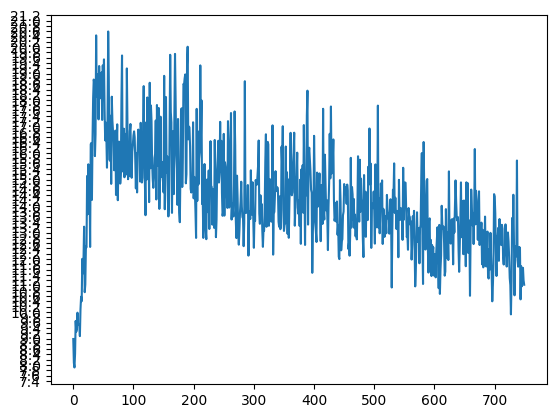

In [ ]:
hidden_size = 256
encoder1 = EncoderRNN(input_lang.n_words, hidden_size).to(device)
decoder1 = DecoderRNN(hidden_size, output_lang.n_words).to(device)

n_iters = 75000
print_every = 5000
trainIters(encoder1, decoder1, n_iters = n_iters, print_every=print_every)


In [ ]:
torch.save(encoder1.state_dict(), 'base1_encoder.pth')
torch.save(decoder1.state_dict(), 'base1_decoder.pth')

In [ ]:
# To evaluate model on the test dataset

gold_texts = []
pred_texts = []

for input_tokens, reference_text in test_pairs:
    with torch.no_grad():
        # Convert input to tensor
        indexes = [input_lang.word2index.get(word, input_lang.word2index['<UNK>']) for word in input_tokens] #if word is missing in train.csv, use UNK
        indexes.append(EOS_token)
        input_tensor = torch.tensor(indexes, dtype=torch.long, device=device).view(-1, 1)

        # Encode
        input_length = input_tensor.size(0)
        encoder_hidden = encoder1.initHidden()
        encoder_outputs = torch.zeros(input_length, encoder1.hidden_size, device=device)

        for ei in range(input_length):
            encoder_output, encoder_hidden = encoder1(input_tensor[ei], encoder_hidden)
            encoder_outputs[ei] = encoder_output[0, 0]

        # Decode
        decoder_input = torch.tensor([[SOS_token]], device=device)
        decoder_hidden = encoder_hidden
        decoded_words = []

        for di in range(250):
            decoder_output, decoder_hidden = decoder1(decoder_input, decoder_hidden)
            topv, topi = decoder_output.topk(1)
            next_word_idx = topi.item()

            if next_word_idx == EOS_token:
                break

            decoded_words.append(output_lang.index2word.get(next_word_idx, '<UNK>'))
            decoder_input = topi.squeeze().detach()

        # Collect results
        predicted_text = ' '.join(decoded_words).strip()
        gold_texts.append(reference_text.strip())
        pred_texts.append(predicted_text)

# To calculate performance metrics
# Tokenize
ref_tokens = [nltk.word_tokenize(text) for text in gold_texts]
hyp_tokens = [nltk.word_tokenize(text) for text in pred_texts]

# BLEU-4 scores
smoothie = SmoothingFunction().method4
bleu_scores = [sentence_bleu([ref], hyp, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)
               for ref, hyp in zip(ref_tokens, hyp_tokens)]
avg_bleu = sum(bleu_scores) / len(bleu_scores)

# METEOR scores
meteor_scores = [meteor_score([ref], hyp) for ref, hyp in zip(ref_tokens, hyp_tokens)]
avg_meteor = sum(meteor_scores) / len(meteor_scores)

# BERTScore
P, R, F1 = score(pred_texts, gold_texts, lang='en', verbose=False)
avg_bertscore_f1 = F1.mean().item()

# Print results
print(f"BLEU-4 Score:  {avg_bleu:.4f}")
print(f"METEOR Score:  {avg_meteor:.4f}")
print(f"BERTScore F1: {avg_bertscore_f1:.4f}")

# To save results to csv
df_results = pd.DataFrame({
    'Input': [' '.join(inp) for inp, _ in test_pairs],
    'Gold': gold_texts,
    'Prediction': pred_texts,
    'BLEU': bleu_scores,
    'METEOR': meteor_scores,
    'BERTScore_F1': F1.tolist()
})
df_results.to_csv('base1_predictions.csv', index=False)
print("Predictions saved to base1_predictions.csv")


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BLEU-4 Score:  0.0013
METEOR Score:  0.0176
BERTScore F1: 0.7396
Predictions saved to base1_predictions.csv


In [ ]:
# To perform qualitative comparison


pred_texts = []

for input_tokens, reference_text in qual_pairs:
    with torch.no_grad():
        # Convert input to tensor
        indexes = [input_lang.word2index.get(word, input_lang.word2index['<UNK>']) for word in input_tokens] #if word is missing in train.csv, ignore
        indexes.append(EOS_token)
        input_tensor = torch.tensor(indexes, dtype=torch.long, device=device).view(-1, 1)

        # Encode
        input_length = input_tensor.size(0)
        encoder_hidden = encoder1.initHidden()
        encoder_outputs = torch.zeros(input_length, encoder1.hidden_size, device=device)

        for ei in range(input_length):
            encoder_output, encoder_hidden = encoder1(input_tensor[ei], encoder_hidden)
            encoder_outputs[ei] = encoder_output[0, 0]

        # Decode
        decoder_input = torch.tensor([[SOS_token]], device=device)
        decoder_hidden = encoder_hidden
        decoded_words = []

        for di in range(250):
            decoder_output, decoder_hidden = decoder1(decoder_input, decoder_hidden)
            topv, topi = decoder_output.topk(1)
            next_word_idx = topi.item()

            if next_word_idx == EOS_token:
                break

            decoded_words.append(output_lang.index2word.get(next_word_idx, '<UNK>'))
            decoder_input = topi.squeeze().detach()

        # Collect results
        predicted_text = ' '.join(decoded_words).strip()
        pred_texts.append(predicted_text)
        print(pred_texts)


['combine first and for minutes .']
['combine first and for minutes .', 'beat bowl']


#### 1.1.2 Sequence-to-Sequence model with attention
Largely references Week 7 Tutorial Part 2 - Seq2Seq with Attention

In [ ]:
# Calculate attention weights to allow the decoder network to “focus” on a different part of the
# encoder’s outputs for every step of the decoder’s own outputs.

class AttnDecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size, dropout_p=0.1):
        super(AttnDecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.dropout_p = dropout_p

        self.embedding = nn.Embedding(self.output_size, self.hidden_size)
        self.dropout = nn.Dropout(self.dropout_p)
        self.gru = nn.GRU(self.hidden_size, self.hidden_size)
        self.out = nn.Linear(self.hidden_size*2, self.output_size)

    def forward(self, input, hidden, encoder_outputs):
        embedded = self.embedding(input).view(1, 1, -1)
        embedded = self.dropout(embedded)

        _, hidden = self.gru(embedded, hidden)

        attn_weights = F.softmax(torch.bmm(hidden, encoder_outputs.T.unsqueeze(0)),dim=-1)
        attn_output = torch.bmm(attn_weights, encoder_outputs.unsqueeze(0))

        concat_output = torch.cat((attn_output[0], hidden[0]), 1)

        output = F.log_softmax(self.out(concat_output), dim=1)

        return output, hidden, attn_weights

    def initHidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)


In [ ]:
# To train the model

teacher_forcing_ratio = 0.5


def train_attn(input_tensor, target_tensor, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion):
    encoder_hidden = encoder.initHidden()

    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()

    input_length = input_tensor.size(0)
    target_length = target_tensor.size(0)

    encoder_outputs = torch.zeros(input_length, encoder.hidden_size, device=device)

    loss = 0

    for ei in range(input_length):
        encoder_output, encoder_hidden = encoder(
            input_tensor[ei], encoder_hidden)
        encoder_outputs[ei] = encoder_output[0, 0]

    decoder_input = torch.tensor([[SOS_token]], device=device)

    decoder_hidden = encoder_hidden

    use_teacher_forcing = True if random.random() < teacher_forcing_ratio else False

    if use_teacher_forcing:
        # Teacher forcing: Feed the target as the next input
        for di in range(target_length):
            decoder_output, decoder_hidden, decoder_attention = decoder(
                decoder_input, decoder_hidden, encoder_outputs)
            loss += criterion(decoder_output, target_tensor[di])
            decoder_input = target_tensor[di]  # Teacher forcing

    else:
        # Without teacher forcing: use its own predictions as the next input
        for di in range(target_length):
            decoder_output, decoder_hidden, decoder_attention = decoder(
                decoder_input, decoder_hidden, encoder_outputs)
            topv, topi = decoder_output.topk(1)
            decoder_input = topi.squeeze().detach()  # detach from history as input

            loss += criterion(decoder_output, target_tensor[di])
            if decoder_input.item() == EOS_token:
                break

    loss.backward()

    encoder_optimizer.step()
    decoder_optimizer.step()

    return loss.item() / target_length


In [ ]:
# To call train iteratively and periodically print the progress
# (% of examples, time so far, estimated time) and average loss.

def trainIters_attn(encoder, decoder, n_iters, print_every=1000, plot_every=100, learning_rate=0.01):
    start = time.time()
    plot_losses = []
    print_loss_total = 0  # Reset every print_every
    plot_loss_total = 0  # Reset every plot_every

    encoder_optimizer = optim.SGD(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.SGD(decoder.parameters(), lr=learning_rate)
    training_pairs = [tensorsFromPair(random.choice(pairs))
                      for i in range(n_iters)]
    criterion = nn.NLLLoss()

    for iter in range(1, n_iters + 1):
        training_pair = training_pairs[iter - 1]
        input_tensor = training_pair[0]
        target_tensor = training_pair[1]

        loss = train_attn(input_tensor, target_tensor, encoder,
                     decoder, encoder_optimizer, decoder_optimizer, criterion)
        print_loss_total += loss
        plot_loss_total += loss

        if iter % print_every == 0:
            print_loss_avg = print_loss_total / print_every
            print_loss_total = 0
            print('%s (%d %d%%) %.4f' % (timeSince(start, iter / n_iters),
                                         iter, iter / n_iters * 100, print_loss_avg))

        if iter % plot_every == 0:
            plot_loss_avg = plot_loss_total / plot_every
            plot_losses.append(plot_loss_avg)
            plot_loss_total = 0

    showPlot(plot_losses)

    # Save plot_losses to a file
    save_losses_to_csv(plot_losses, 'losses_base2.csv')


5m 26s (- 76m 5s) (5000 6%) 4.6313
10m 53s (- 70m 47s) (10000 13%) 4.2885
16m 17s (- 65m 9s) (15000 20%) 4.2821
21m 48s (- 59m 57s) (20000 26%) 4.2733
27m 20s (- 54m 41s) (25000 33%) 4.2158
32m 51s (- 49m 17s) (30000 40%) 4.1979
38m 27s (- 43m 56s) (35000 46%) 4.2286
44m 6s (- 38m 35s) (40000 53%) 4.2415
49m 46s (- 33m 11s) (45000 60%) 4.2008
55m 18s (- 27m 39s) (50000 66%) 4.1809
60m 57s (- 22m 9s) (55000 73%) 4.1973
66m 31s (- 16m 37s) (60000 80%) 4.1793
72m 3s (- 11m 5s) (65000 86%) 4.2543
77m 17s (- 5m 31s) (70000 93%) 5.8286
82m 20s (- 0m 0s) (75000 100%) 5.9050


<Figure size 640x480 with 0 Axes>

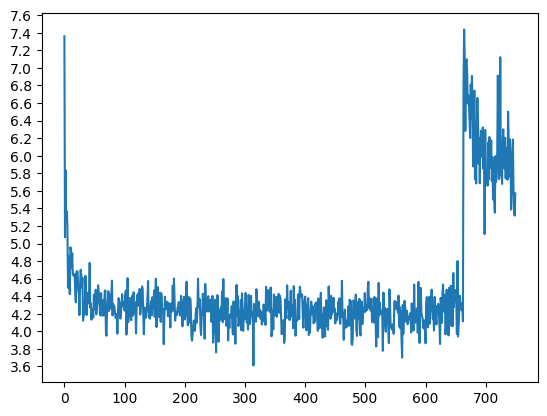

In [ ]:
hidden_size = 256
encoder = EncoderRNN(input_lang.n_words, hidden_size).to(device)
attn_decoder = AttnDecoderRNN(hidden_size, output_lang.n_words, dropout_p=0.1).to(device)

n_iters = 75000
print_every = 5000

trainIters_attn(encoder, attn_decoder, n_iters= n_iters, print_every=print_every)

In [ ]:
torch.save(encoder.state_dict(), 'base2_encoder.pth')
torch.save(attn_decoder.state_dict(), 'base2_decoder.pth')

In [ ]:
gold_texts = []
pred_texts = []

for input_tokens, reference_text in test_pairs:
    with torch.no_grad():
        # --- Encode ---
        input_sentence = ' '.join(input_tokens)
        # Convert only known words to indices
        input_indices = [input_lang.word2index.get(word, input_lang.word2index['<UNK>']) for word in input_tokens]
        input_indices.append(EOS_token)

        # Convert to tensor
        input_tensor = torch.tensor(input_indices, dtype=torch.long, device=device).view(-1, 1)
        input_length = input_tensor.size(0)

        encoder_hidden = encoder.initHidden()
        encoder_outputs = torch.zeros(input_length, encoder.hidden_size, device=device)

        for ei in range(input_length):
            encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
            encoder_outputs[ei] = encoder_output[0, 0]

        # --- Decode ---
        decoder_input = torch.tensor([[SOS_token]], device=device)
        decoder_hidden = encoder_hidden

        decoded_words = []

        for di in range(250):  # max length
            decoder_output, decoder_hidden, _ = attn_decoder(decoder_input, decoder_hidden, encoder_outputs)
            topv, topi = decoder_output.data.topk(1)
            next_token = topi.item()

            if topi.item() == EOS_token:
                break

            decoded_words.append(output_lang.index2word.get(next_token, '<UNK>'))
            decoder_input = topi.squeeze().detach().view(1, 1)

        predicted_text = ' '.join(decoded_words).strip()
        gold_texts.append(reference_text.strip())
        pred_texts.append(predicted_text)



# Tokenize for BLEU
ref_tokens = [nltk.word_tokenize(text) for text in gold_texts]
hyp_tokens = [nltk.word_tokenize(text) for text in pred_texts]

# BLEU-4 with smoothing
smoothie = SmoothingFunction().method4
bleu_scores = [sentence_bleu([ref], hyp, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)
               for ref, hyp in zip(ref_tokens, hyp_tokens)]
avg_bleu = sum(bleu_scores) / len(bleu_scores)

# METEOR
meteor_scores = [meteor_score([ref], hyp) for ref, hyp in zip(ref_tokens, hyp_tokens)]
avg_meteor = sum(meteor_scores) / len(meteor_scores)

# BERTScore
P, R, F1 = score(pred_texts, gold_texts, lang='en', verbose=False)
avg_bertscore_f1 = F1.mean().item()

# Print results
print(f"BLEU-4 Score:  {avg_bleu:.4f}")
print(f"METEOR Score:  {avg_meteor:.4f}")
print(f"BERTScore F1: {avg_bertscore_f1:.4f}")

# Save to csv
df_results = pd.DataFrame({
    'Input': [' '.join(inp) for inp, _ in test_pairs],
    'Gold': gold_texts,
    'Prediction': pred_texts,
    'BLEU': bleu_scores,
    'METEOR': meteor_scores,
    'BERTScore_F1': F1.tolist()
})
df_results.to_csv('base2_predictions.csv', index=False)
print("Predictions saved to base2_predictions.csv")



Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BLEU-4 Score:  0.0115
METEOR Score:  0.1438
BERTScore F1: 0.7957
Predictions saved to base2_predictions.csv


In [ ]:
# To perform qualitative comparison

pred_texts = []

for input_tokens, reference_text in qual_pairs:
    with torch.no_grad():
        # --- Encode ---
        input_sentence = ' '.join(input_tokens)
        # Convert only known words to indices
        input_indices = [input_lang.word2index.get(word, input_lang.word2index['<UNK>']) for word in input_tokens]
        input_indices.append(EOS_token)

        # Convert to tensor
        input_tensor = torch.tensor(input_indices, dtype=torch.long, device=device).view(-1, 1)
        input_length = input_tensor.size(0)

        encoder_hidden = encoder.initHidden()
        encoder_outputs = torch.zeros(input_length, encoder.hidden_size, device=device)

        for ei in range(input_length):
            encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
            encoder_outputs[ei] = encoder_output[0, 0]

        # --- Decode ---
        decoder_input = torch.tensor([[SOS_token]], device=device)
        decoder_hidden = encoder_hidden

        decoded_words = []

        for di in range(250):  # max length
            decoder_output, decoder_hidden, _ = attn_decoder(decoder_input, decoder_hidden, encoder_outputs)
            topv, topi = decoder_output.data.topk(1)
            next_token = topi.item()

            if topi.item() == EOS_token:
                break

            decoded_words.append(output_lang.index2word.get(next_token, '<UNK>'))
            decoder_input = topi.squeeze().detach().view(1, 1)


        # Collect results
        predicted_text = ' '.join(decoded_words).strip()
        pred_texts.append(predicted_text)
        print(pred_texts)


['mix sugar and to mix to to to to to to to to . simmer for minutes until mixture and or in oven cool for to hours for until and or until whipped and freeze until smooth and or until thick and cup to package directions for to minutes until cool to to to room temperature until and beef or . for mix to minutes . add to mix powdered to . mix to to to to to to to to to taste . simmer for mix and cool for to room temperature until and smooth and add to mix to . for to hours or until and to coat . chill . put on to top with cool and to cook and over . . . . . . add to powdered hot . add and mix well . or hour to to . mix to taste .']
['mix sugar and to mix to to to to to to to to . simmer for minutes until mixture and or in oven cool for to hours for until and or until whipped and freeze until smooth and or until thick and cup to package directions for to minutes until cool to to to room temperature until and beef or . for mix to minutes . add to mix powdered to . mix to to to to to to to to

### 1.2 The 2 Mild Extensions🌶️🌶️


#### 1.2.1 Seq2Seq model with attention AND pretrained embeddings
Largely references Week 8 Tutorial for using pretrained embeddings (i.e., GLoVe). Other refinements implemented include:
- Linearly decaying teacher forcing ratio from 1.0 to 0.2
- Adapting learning rate based on validation loss
- Changed optimizer from SGD to Adam
- Stacked two layers of GRU
- Added layer normalization
- Using beam search NOT greedy during prediction

In [ ]:
## CHANGE: USING pretrained GLoVe embeddings
embedding_dim = 300
def load_embeddings(embedding_file, vocab_lang):
  embeddings = np.zeros((vocab_lang.n_words, embedding_dim))
  with open(embedding_file, encoding='utf-8', newline='\n', errors='ignore') as f:
    for line in f:
        word, vect = line.rstrip().split(' ', 1)
        vect = np.fromstring(vect, sep=' ')
        if word in vocab_lang.word2index:
          embeddings[vocab_lang.word2index[word]] = vect
  embeddings = torch.from_numpy(embeddings).float()
  return embeddings

ingredient_embedding = load_embeddings("glove.6B.300d.txt", input_lang)
recipe_embedding = load_embeddings("glove.6B.300d.txt", output_lang)

In [ ]:
# An encoder to read an input sequence and outputs a single context vector,
# which captures the meaning of the entire vector sequence

class EncoderRNN(nn.Module):
    def __init__(self, input_size, embedding_size, hidden_size, pretrained_embeddings=None):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding_size = embedding_size

        # CHANGE: load pretrained embedding if any
        if pretrained_embeddings is not None:
          self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings)
        else:
          self.embedding = nn.Embedding(input_size, embedding_size)

        self.gru = nn.GRU(embedding_size, hidden_size, num_layers=2, dropout=0.2) # CHANGE: using two GRU layers
        self.layer_norm = nn.LayerNorm(hidden_size) # CHANGE: applying layer normalisation

    def forward(self, input, hidden):
        embedded = self.embedding(input).view(1, 1, -1)
        output = embedded
        output, hidden = self.gru(output, hidden) # CHANGE: using two GRU layers
        output = self.layer_norm(output) # CHANGE: applying layer normalisation
        return output, hidden

    def initHidden(self):
        return torch.zeros(2, 1, self.hidden_size, device=device)

In [ ]:
# Calculate attention weights to allow the decoder network to “focus” on a different part of the
# encoder’s outputs for every step of the decoder’s own outputs.

class AttnDecoderRNN(nn.Module):
    def __init__(self, embedding_size, hidden_size, output_size, dropout_p=0.1, max_length=300, pretrained_embeddings=None):
        super(AttnDecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding_size = embedding_size
        self.output_size = output_size
        self.dropout_p = dropout_p
        self.max_length = max_length

        # CHANGE: load pretrained embedding if any
        if pretrained_embeddings is not None:
          self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings)
        else:
          self.embedding = nn.Embedding(self.output_size, self.embedding_size)

        self.attn = nn.Linear(self.hidden_size + self.embedding_size, self.max_length)
        self.attn_combine = nn.Linear(self.hidden_size + self.embedding_size, self.hidden_size)
        self.dropout = nn.Dropout(self.dropout_p)

        self.gru = nn.GRU(self.hidden_size, self.hidden_size, num_layers=2, dropout=0.2) # CHANGE: using two GRU layers
        self.layer_norm = nn.LayerNorm(hidden_size) # CHANGE: applying layer normalisation
        self.out = nn.Linear(self.hidden_size, self.output_size)

    def forward(self, input, hidden, encoder_outputs):
        embedded = self.embedding(input).view(1, 1, -1)
        embedded = self.dropout(embedded)

        attn_weights = F.softmax(
            self.attn(torch.cat((embedded[0], hidden[0]), 1)), dim=1)
        attn_applied = torch.bmm(attn_weights.unsqueeze(0),
                                 encoder_outputs.unsqueeze(0))

        output = torch.cat((embedded[0], attn_applied[0]), 1)
        output = self.attn_combine(output).unsqueeze(0)

        output = F.relu(output)
        output, hidden = self.gru(output, hidden) # CHANGE: using two GRU layers
        output = self.layer_norm(output) # CHANGE: applying layer normalisation

        output = F.log_softmax(self.out(output[0]), dim=1)
        return output, hidden, attn_weights

    def initHidden(self):
        return torch.zeros(2, 1, self.hidden_size, device=device)

In [ ]:
# To train the model

def train_attn(teacher_forcing_ratio, input_tensor, target_tensor, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion, max_length=300):
    encoder_hidden = encoder.initHidden()

    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()

    input_length = min(input_tensor.size(0), max_length) # in case it exceeds max_length
    target_length = target_tensor.size(0)

    encoder_outputs = torch.zeros(max_length, encoder.hidden_size, device=device)

    loss = 0

    for ei in range(input_length):
        encoder_output, encoder_hidden = encoder(
            input_tensor[ei], encoder_hidden)
        encoder_outputs[ei] = encoder_output[0, 0]

    decoder_input = torch.tensor([[SOS_token]], device=device)

    decoder_hidden = encoder_hidden

    use_teacher_forcing = True if random.random() < teacher_forcing_ratio else False

    if use_teacher_forcing:
        # Teacher forcing: Feed the target as the next input
        for di in range(target_length):
            decoder_output, decoder_hidden, decoder_attention = decoder(
                decoder_input, decoder_hidden, encoder_outputs)
            loss += criterion(decoder_output, target_tensor[di])
            decoder_input = target_tensor[di]  # Teacher forcing

    else:
        # Without teacher forcing: use its own predictions as the next input
        for di in range(target_length):
            decoder_output, decoder_hidden, decoder_attention = decoder(
                decoder_input, decoder_hidden, encoder_outputs)
            topv, topi = decoder_output.topk(1)
            decoder_input = topi.squeeze().detach()  # detach from history as input

            loss += criterion(decoder_output, target_tensor[di])
            if decoder_input.item() == EOS_token:
                break

    loss.backward()

    # CHANGE: applying gradient clipping to prevent gradient explosion
    torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1.0)
    torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=1.0)

    encoder_optimizer.step()
    decoder_optimizer.step()

    return loss.item() / target_length


In [ ]:
# CHANGE: track validation loss to allow adaptive learning rate

def evaluate_loss(encoder, decoder, val_pairs, criterion, max_length=300):
    encoder.eval()
    decoder.eval()

    total_loss = 0

    with torch.no_grad():
        for pair in val_pairs:
            input_tensor, target_tensor = tensorsFromPair(pair)
            input_length = min(input_tensor.size(0), max_length) #in case it exceeds max_length
            target_length = target_tensor.size(0)

            encoder_hidden = encoder.initHidden()
            encoder_outputs = torch.zeros(max_length, encoder.hidden_size, device=device)

            for ei in range(input_length):
                encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
                encoder_outputs[ei] = encoder_output[0, 0]

            decoder_input = torch.tensor([[SOS_token]], device=device)
            decoder_hidden = encoder_hidden

            loss = 0
            for di in range(target_length):
                decoder_output, decoder_hidden, decoder_attention = decoder(
                    decoder_input, decoder_hidden, encoder_outputs)
                loss += criterion(decoder_output, target_tensor[di])
                topv, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze().detach()
                if decoder_input.item() == EOS_token:
                    break

            total_loss += loss.item() / target_length

    encoder.train()
    decoder.train()
    return total_loss / len(val_pairs)


In [ ]:
# To call train iteratively and periodically print the progress
# (% of examples, time so far, estimated time) and average loss.

from torch.optim.lr_scheduler import ReduceLROnPlateau

def trainIters_attn(encoder, decoder, n_iters, print_every=1000, plot_every=100, learning_rate=0.001): # CHANGE: using a lower learning rate of 0.001
    start = time.time()
    plot_losses = []
    print_loss_total = 0  # Reset every print_every
    plot_loss_total = 0  # Reset every plot_every

    encoder_optimizer = optim.Adam(encoder.parameters(), lr=learning_rate) # CHANGE: using Adam optimizer
    decoder_optimizer = optim.Adam(decoder.parameters(), lr=learning_rate)

    encoder_scheduler = ReduceLROnPlateau(encoder_optimizer)
    decoder_scheduler = ReduceLROnPlateau(decoder_optimizer)


    training_pairs = [tensorsFromPair(random.choice(pairs))
                      for i in range(n_iters)]
    criterion = nn.NLLLoss()

    for iter in range(1, n_iters + 1):

        # CHANGE: Gradually decay teacher forcing; reaches 0.2 at 65000 iterations
        teacher_forcing_ratio = max(0.2, 1.0 - (iter * 0.000012))

        training_pair = training_pairs[iter - 1]
        input_tensor = training_pair[0]
        target_tensor = training_pair[1]

        loss = train_attn(teacher_forcing_ratio, input_tensor, target_tensor, encoder,
                     decoder, encoder_optimizer, decoder_optimizer, criterion)
        print_loss_total += loss
        plot_loss_total += loss


        # CHANGE: Reduces learning rate if validation loss stops improving
        if iter % 500 == 0 or iter % print_every == 0:
            val_loss = evaluate_loss(encoder, decoder, val_pairs, criterion)

        if iter % 500 == 0:
            encoder_scheduler.step(val_loss)
            decoder_scheduler.step(val_loss)


        if iter % print_every == 0:
            print_loss_avg = print_loss_total / print_every
            print_loss_total = 0
            print('%s (%d %d%%) %.4f %.4f' % (timeSince(start, iter / n_iters),
                                         iter, iter / n_iters * 100, print_loss_avg, val_loss))


        if iter % plot_every == 0:
            plot_loss_avg = plot_loss_total / plot_every
            plot_losses.append(plot_loss_avg)
            plot_loss_total = 0

    showPlot(plot_losses)


    # Save plot_losses to a file
    save_losses_to_csv(plot_losses, 'losses_mild2.csv')


12m 5s (- 169m 11s) (5000 6%) 3.8982 2.8831
23m 52s (- 155m 12s) (10000 13%) 3.3662 4.0870
35m 49s (- 143m 19s) (15000 20%) 3.2849 4.2043
48m 21s (- 132m 58s) (20000 26%) 3.4217 4.4428
60m 50s (- 121m 40s) (25000 33%) 3.4716 4.5115
73m 15s (- 109m 53s) (30000 40%) 3.5070 4.5161
85m 33s (- 97m 47s) (35000 46%) 3.6033 4.5169
97m 44s (- 85m 31s) (40000 53%) 3.6444 4.5198
109m 49s (- 73m 12s) (45000 60%) 3.6953 4.5240
121m 53s (- 60m 56s) (50000 66%) 3.7975 4.5259
133m 53s (- 48m 41s) (55000 73%) 3.8674 4.5318
145m 49s (- 36m 27s) (60000 80%) 3.9528 4.5325
157m 38s (- 24m 15s) (65000 86%) 3.9944 4.5320
169m 20s (- 12m 5s) (70000 93%) 4.0555 4.5359
181m 3s (- 0m 0s) (75000 100%) 4.0651 4.5418


<Figure size 640x480 with 0 Axes>

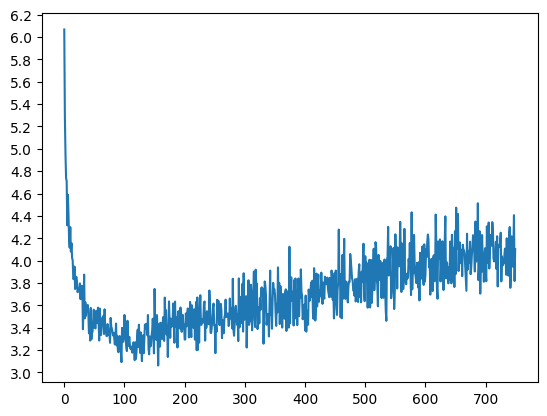

In [ ]:
hidden_size = 256
embedding_size = 300
encoder = EncoderRNN(input_lang.n_words, embedding_size, hidden_size, pretrained_embeddings=ingredient_embedding).to(device)
attn_decoder = AttnDecoderRNN(embedding_size, hidden_size, output_lang.n_words, dropout_p=0.1, pretrained_embeddings=recipe_embedding).to(device)

n_iters = 75000
print_every = 5000

trainIters_attn(encoder, attn_decoder, n_iters= n_iters, print_every=print_every)

In [ ]:
torch.save(encoder.state_dict(), 'mild2_encoder.pth')
torch.save(attn_decoder.state_dict(), 'mild2_decoder.pth')

In [ ]:
# CHANGE: replaced greedy decoding with beam search
def beam_search_decode(encoder, decoder, input_tensor, beam_width=3, max_length=300, ngram_size=2, length_penalty=0.7):
    encoder_hidden = encoder.initHidden()
    input_length = min(input_tensor.size(0), max_length)
    encoder_outputs = torch.zeros(max_length, encoder.hidden_size, device=device)

    for ei in range(input_length):
        encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
        encoder_outputs[ei] = encoder_output[0, 0]

    decoder_hidden = encoder_hidden
    decoder_input = torch.tensor([[SOS_token]], device=device)

    beams = [(decoder_input, decoder_hidden, [], 0.0, False)]  # (current input token, decoder hidden state, output sequence, cumulative log-probability, eos flag))

    for _ in range(max_length):
        all_candidates = []

        for decoder_input, decoder_hidden, output_seq, cum_log_prob, eos_reached in beams:
            if eos_reached: # If EOS is already reached for this beam, keep it as-is
                all_candidates.append((decoder_input, decoder_hidden, output_seq, cum_log_prob, eos_reached))
                continue

            decoder_output, decoder_hidden, _ = decoder(decoder_input, decoder_hidden, encoder_outputs)
            log_probs, top_indices = torch.topk(decoder_output, beam_width * 2) # Get top token predictions (twice the beam width to allow for pruning bad n-gram candidates)

            candidates = 0
            for i in range(log_probs.size(1)):
                token = top_indices[0][i].item()
                log_prob = log_probs[0][i].item()

                new_output_seq = output_seq + [token]

                # N-gram repetition blocking
                if len(new_output_seq) >= ngram_size:
                    ngram = tuple(new_output_seq[-ngram_size:])
                    prev_ngrams = set(tuple(new_output_seq[j:j+ngram_size]) for j in range(len(new_output_seq) - ngram_size))
                    if ngram in prev_ngrams:
                        continue

                new_cum_log_prob = cum_log_prob + log_prob
                eos_hit = token == EOS_token # Check if EOS token was generated

                # Append the candidate to all_candidates
                all_candidates.append((
                    torch.tensor([[token]], device=device),
                    decoder_hidden,
                    new_output_seq,
                    new_cum_log_prob,
                    eos_hit
                ))
                candidates += 1
                if candidates >= beam_width: # Only keep beam_width candidates per beam
                    break

        if not all_candidates:
            break

        # Rank candidates using length penalty (to favor longer, but meaningful sequences)
        beams = sorted(
            all_candidates,
            key=lambda x: x[3] / ((len(x[2]) ** length_penalty) if len(x[2]) > 0 else 1),
            reverse=True
        )[:beam_width]

        # If all beams have reached EOS, stop early
        if all(b[4] for b in beams):
            break

    # Prefer complete sequences with EOS
    final_seq = None
    for beam in beams:
        if beam[4]:  # eos_reached
            final_seq = beam[2]
            break
    if final_seq is None: # If no beam finished with EOS, use the best scoring one
        final_seq = beams[0][2]

    return [output_lang.index2word.get(tok, '<UNK>') for tok in final_seq if tok != EOS_token]


In [ ]:
gold_texts = []
pred_texts = []
max_length = 250


for input_tokens, reference_text in test_pairs:
    with torch.no_grad():

        # Encode
        input_sentence = ' '.join(input_tokens)
        # Convert only known words to indices
        input_indices = [input_lang.word2index.get(word, input_lang.word2index['<UNK>']) for word in input_tokens]
        input_indices.append(EOS_token)

        # Convert to tensor
        input_tensor = torch.tensor(input_indices, dtype=torch.long, device=device).view(-1, 1)

        decoded_words = beam_search_decode(encoder, attn_decoder, input_tensor)

        predicted_text = ' '.join(decoded_words).strip()
        gold_texts.append(reference_text.strip())
        pred_texts.append(predicted_text)



# Tokenize for BLEU
ref_tokens = [nltk.word_tokenize(text) for text in gold_texts]
hyp_tokens = [nltk.word_tokenize(text) for text in pred_texts]

# BLEU-4 with smoothing
smoothie = SmoothingFunction().method4
bleu_scores = [sentence_bleu([ref], hyp, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)
               for ref, hyp in zip(ref_tokens, hyp_tokens)]
avg_bleu = sum(bleu_scores) / len(bleu_scores)

# METEOR
meteor_scores = [meteor_score([ref], hyp) for ref, hyp in zip(ref_tokens, hyp_tokens)]
avg_meteor = sum(meteor_scores) / len(meteor_scores)

# BERTScore
P, R, F1 = score(pred_texts, gold_texts, lang='en', verbose=False)
avg_bertscore_f1 = F1.mean().item()

# Print results
print(f"BLEU-4 Score:  {avg_bleu:.4f}")
print(f"METEOR Score:  {avg_meteor:.4f}")
print(f"BERTScore F1: {avg_bertscore_f1:.4f}")

# Save to csv
df_results = pd.DataFrame({
    'Input': [' '.join(inp) for inp, _ in test_pairs],
    'Gold': gold_texts,
    'Prediction': pred_texts,
    'BLEU': bleu_scores,
    'METEOR': meteor_scores,
    'BERTScore_F1': F1.tolist()
})
df_results.to_csv('mild2_predictions.csv', index=False)
print("Predictions saved to mild2_predictions.csv")


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BLEU-4 Score:  0.0214
METEOR Score:  0.1413
BERTScore F1: 0.8369
Predictions saved to mild2_predictions.csv


In [ ]:
# To perform qualitative comparison

pred_texts = []

for input_tokens, reference_text in qual_pairs:
    with torch.no_grad():

        # Encode
        input_sentence = ' '.join(input_tokens)
        # Convert only known words to indices
        input_indices = [input_lang.word2index.get(word, input_lang.word2index['<UNK>']) for word in input_tokens]
        input_indices.append(EOS_token)

        # Convert to tensor
        input_tensor = torch.tensor(input_indices, dtype=torch.long, device=device).view(-1, 1)

        decoded_words = beam_search_decode(encoder, attn_decoder, input_tensor)

        # Collect results
        predicted_text = ' '.join(decoded_words).strip()
        pred_texts.append(predicted_text)
        print(pred_texts)



['combine all ingredients and mix well . chill overnight .']
['combine all ingredients and mix well . chill overnight .', 'in a large bowl . combine all ingredients . bring to a boil . reduce heat and simmer minutes .']


#### 1.2.2 Sequence-to-Sequence model with attention AND additional preprocessing

Builds upon the Mild 1 model.

Fulfils the following requirement: *Preprocessing the data beyond simple lowercasing/stop-word removal/lemmatization/stemming (i.e., removing measurement units in the ingredients list, padding recipe sentences, vocabulary pruning, etc).*

Ingredients are processed to only include core ingredient names and preparation technique (units and quantities are removed). Recipes are processed to include non-letter characters such as numbers.

In [ ]:
# To encode each word as a one-hot vector

SOS_token = 0
EOS_token = 1


class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {"SOS": 0, "EOS": 1, "<UNK>": 2}
        self.word2count = {}
        self.index2word = {0: "SOS", 1: "EOS", 2: "<UNK>"}
        self.n_words = 3  # Count SOS and EOS

    def addSentence(self, sentence):
        for word in sentence.split(' '):
            self.addWord(word)

    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

In [ ]:
# Turn a Unicode string to plain ASCII (https://stackoverflow.com/a/518232/2809427)
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

# Lowercase and trim
# CHANGE: Normalization for recipe does not remove non-letter characters
def normalizeString(s):
    s = unicodeToAscii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s)
    #s = re.sub(r"[^a-zA-Z.!?]+", r" ", s)
    return s

# To process each list per row
def normalizeListString(list_str):
    try:
        parsed = ast.literal_eval(list_str)
        return normalizeString(' '.join(parsed))
    except:
        return normalizeString(list_str)

In [ ]:
# CHANGE: Normalization only for ingredients
def normalizeIngString(s):
    # # Lowercase, trim, and remove non-letter characters
    s = unicodeToAscii(s.lower().strip())
    s = re.sub(r"([.!?])", r"", s)
    s = re.sub(r"[^a-zA-Z\-\.!?]+", r" ", s)
    # remove stop words
    s = re.sub(r"\b(and|or|if|of|with|the|at|from|in)\b", "", s)
    #Removing MealMaster amount codes, following dataset authors, Kiddon et al. (2016)
    s = re.sub(r"\b(x|sm|md|lg|tsp|tbsp|oz|lb|pkg|cn|pk|pn|dr|ds|ct|bn|sl|ea|t|ts|T|tb|fl|c|pt|qt|ga|ml|cb|cl|dl|l|mg|cg|dg|g|kg)\.?\b", "", s)
    # Remove anything inside parentheses (e.g., (8 oz.), (optional), etc.)
    s = re.sub(r'\([^)]*\)', '', s)
    return s


## CHANGE
from ingredient_parser import parse_ingredient
# This package accurately parses structured information out of recipe ingredient sentences.
# For example, if you run: parse_ingredient("1 (17 oz.) can dark sweet pitted cherries")
# output: ParsedIngredient(name=[IngredientText(text='dark sweet pitted cherries', confidence=0.998312, starting_index=6)], size=None, amount=[IngredientAmount(quantity=Fraction(1, 1), quantity_max=Fraction(1, 1), unit='can', text='1 can', confidence=0.997386, starting_index=0, APPROXIMATE=False, SINGULAR=False, RANGE=False, MULTIPLIER=False, PREPARED_INGREDIENT=False), IngredientAmount(quantity=Fraction(17, 1), quantity_max=Fraction(17, 1), unit=<Unit('ounce')>, text='17 oz', confidence=0.999921, starting_index=2, APPROXIMATE=False, SINGULAR=True, RANGE=False, MULTIPLIER=False, PREPARED_INGREDIENT=False)], preparation=None, comment=None, purpose=None, foundation_foods=[], sentence='1 (17 oz.) can dark sweet pitted cherries')
# Find more information here: https://github.com/strangetom/ingredient-parser

def clean_ingredient_list(ingredient_list_str):
    try:
        parsed = ast.literal_eval(ingredient_list_str)
        parsed_names = []
        for line in parsed:
            result = parse_ingredient(line)
            name = result.name[0].text  # This is the core ingredient with no measurement units
            if name:
                parsed_names.append(name.lower().strip())
                if result.preparation:
                    parsed_names.append(result.preparation.text.lower().strip())
        return ' '.join(parsed_names)
    except:
        return normalizeIngString(ingredient_list_str)  # fallback if ingredient cannot be parsed


In [ ]:
def readLangs_from_csv(csv_path):
    print("Reading CSV lines...")
    pairs = []

    with open(csv_path, encoding='utf-8') as csvfile:
        reader = csv.DictReader(csvfile)
        for row in reader:
            # Join ingredients and recipe steps into strings
            ing = clean_ingredient_list(row["Ingredients"])
            rec = normalizeListString(row["Recipe"])
            pairs.append([ing, rec])

    input_lang = Lang("ingredients")
    output_lang = Lang("recipe")

    return input_lang, output_lang, pairs


In [ ]:
# Full process for preparing the data using the above functions

def prepareData_from_csv(csv_path):
    input_lang, output_lang, pairs = readLangs_from_csv(csv_path)
    print(f"Read {len(pairs)} sentence pairs")
    print("Counting words...")
    for pair in pairs:
        input_lang.addSentence(pair[0])
        output_lang.addSentence(pair[1])
    print("Counted words:")
    print(input_lang.name, input_lang.n_words)
    print(output_lang.name, output_lang.n_words)
    return input_lang, output_lang, pairs

In [ ]:
# Processing training data

input_lang, output_lang, pairs = prepareData_from_csv('train.csv')
print(random.choice(pairs))

Reading CSV lines...
Read 162899 sentence pairs
Counting words...
Counted words:
ingredients 13135
recipe 30749
['graham crackers instant vanilla pudding cool whip chocolate frosting', 'mix pudding according to package and cool . mix pudding and cool whip until creamy . layer graham crackers and pudding mixture, keep layering until graham crackers are on top . top with icing and chill .']


In [ ]:
# Processing test data

test_input_lang, test_output_lang, test_pairs = prepareData_from_csv('test.csv')
print(random.choice(test_pairs))

Reading CSV lines...
Read 1081 sentence pairs
Counting words...
Counted words:
ingredients 1364
recipe 3017
['mushrooms chopped clams drained dried basil leaves fresh parsley snipped parmesan cheese grated almonds fresh garlic olive oil chicken broth spaghetti noodles', 'chop mushrooms and saute with 2 tablespoons olive oil in a large frying pan; set aside .']


In [ ]:
# Processing training data

val_input_lang, val_output_lang, val_pairs = prepareData_from_csv('dev.csv')
print(random.choice(val_pairs))

Reading CSV lines...
Read 1065 sentence pairs
Counting words...
Counted words:
ingredients 1428
recipe 3044
['pkg. cream cheese mushrooms black olives* dried beef* green olives* accent pecans chopped', '*chopped or can be put in blender .']


In [ ]:
# Processing qualitative comparison data

qual_input_lang, qual_output_lang, qual_pairs = prepareData_from_csv('qual.csv')
print(qual_pairs)

Reading CSV lines...
Read 2 sentence pairs
Counting words...
Counted words:
ingredients 25
recipe 6
[['sugar lemon juice water orange juice strawberries icecream', 'na .'], ['philadelphia cream cheese sweetened condensed milk ts vanilla lemon juice canned cherries graham cracker pie crusts', 'na .']]


In [ ]:
ingredient_embedding = load_embeddings("glove.6B.300d.txt", input_lang)
recipe_embedding = load_embeddings("glove.6B.300d.txt", output_lang)

In [ ]:
# To call train iteratively and periodically print the progress
# (% of examples, time so far, estimated time) and average loss.

from torch.optim.lr_scheduler import ReduceLROnPlateau

def trainIters_attn(encoder, decoder, n_iters, print_every=1000, plot_every=100, learning_rate=0.001):
    start = time.time()
    plot_losses = []
    print_loss_total = 0  # Reset every print_every
    plot_loss_total = 0  # Reset every plot_every

    encoder_optimizer = optim.Adam(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.Adam(decoder.parameters(), lr=learning_rate)

    encoder_scheduler = ReduceLROnPlateau(encoder_optimizer)
    decoder_scheduler = ReduceLROnPlateau(decoder_optimizer)


    training_pairs = [tensorsFromPair(random.choice(pairs))
                      for i in range(n_iters)]
    criterion = nn.NLLLoss()

    for iter in range(1, n_iters + 1):

        # Gradually decay teacher forcing; reaches 0.2 at 65000 iterations
        teacher_forcing_ratio = max(0.2, 1.0 - (iter * 0.000012))

        training_pair = training_pairs[iter - 1]
        input_tensor = training_pair[0]
        target_tensor = training_pair[1]

        loss = train_attn(teacher_forcing_ratio, input_tensor, target_tensor, encoder,
                     decoder, encoder_optimizer, decoder_optimizer, criterion)
        print_loss_total += loss
        plot_loss_total += loss


        # Reduces learning rate if validation loss stops improving
        if iter % 500 == 0 or iter % print_every == 0:
            val_loss = evaluate_loss(encoder, decoder, val_pairs, criterion)

        if iter % 500 == 0:
            encoder_scheduler.step(val_loss)
            decoder_scheduler.step(val_loss)


        if iter % print_every == 0:
            print_loss_avg = print_loss_total / print_every
            print_loss_total = 0
            print('%s (%d %d%%) %.4f %.4f' % (timeSince(start, iter / n_iters),
                                         iter, iter / n_iters * 100, print_loss_avg, val_loss))


        if iter % plot_every == 0:
            plot_loss_avg = plot_loss_total / plot_every
            plot_losses.append(plot_loss_avg)
            plot_loss_total = 0

    showPlot(plot_losses)


    # Save plot_losses to a file
    save_losses_to_csv(plot_losses, 'losses_mild1.csv')

10m 15s (- 143m 43s) (5000 6%) 4.1558 2.0754
20m 8s (- 130m 54s) (10000 13%) 3.5804 3.5925
31m 6s (- 124m 24s) (15000 20%) 3.5032 4.6326
42m 33s (- 117m 3s) (20000 26%) 3.6021 4.8789
54m 10s (- 108m 21s) (25000 33%) 3.6965 4.9709
65m 42s (- 98m 33s) (30000 40%) 3.7767 5.0308
77m 8s (- 88m 10s) (35000 46%) 3.8630 5.0259
88m 36s (- 77m 32s) (40000 53%) 3.9657 5.0258
100m 0s (- 66m 40s) (45000 60%) 4.0431 5.0263
111m 19s (- 55m 39s) (50000 66%) 4.1097 5.0293
122m 37s (- 44m 35s) (55000 73%) 4.2757 5.0268
133m 47s (- 33m 26s) (60000 80%) 4.2975 5.0266
144m 55s (- 22m 17s) (65000 86%) 4.4281 5.0249
155m 58s (- 11m 8s) (70000 93%) 4.4541 5.0269
167m 4s (- 0m 0s) (75000 100%) 4.4827 5.0320


<Figure size 640x480 with 0 Axes>

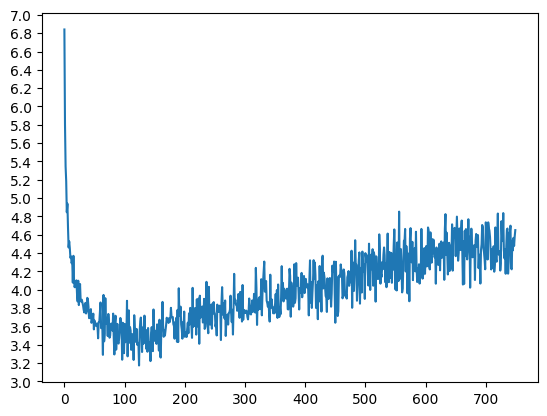

In [ ]:
hidden_size = 256
embedding_size = 300
encoder = EncoderRNN(input_lang.n_words, embedding_size, hidden_size, pretrained_embeddings=ingredient_embedding).to(device)
attn_decoder = AttnDecoderRNN(embedding_size, hidden_size, output_lang.n_words, dropout_p=0.1, pretrained_embeddings=recipe_embedding).to(device)

n_iters = 75000
print_every = 5000

trainIters_attn(encoder, attn_decoder, n_iters= n_iters, print_every=print_every)

In [ ]:
torch.save(encoder.state_dict(), 'mild1_encoder.pth')
torch.save(attn_decoder.state_dict(), 'mild1_decoder.pth')

In [ ]:
gold_texts = []
pred_texts = []

for input_tokens, reference_text in test_pairs:
    with torch.no_grad():
        # Encode
        input_sentence = ' '.join(input_tokens)
        # Convert only known words to indices
        input_indices = [input_lang.word2index.get(word, input_lang.word2index['<UNK>']) for word in input_tokens]
        input_indices.append(EOS_token)

        # Convert to tensor
        input_tensor = torch.tensor(input_indices, dtype=torch.long, device=device).view(-1, 1)
        input_length = input_tensor.size(0)

        encoder_hidden = encoder.initHidden()
        encoder_outputs = torch.zeros(input_length, encoder.hidden_size, device=device)

        for ei in range(input_length):
            encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
            encoder_outputs[ei] = encoder_output[0, 0]

        # Decode
        decoded_words = beam_search_decode(encoder, attn_decoder, input_tensor)

        predicted_text = ' '.join(decoded_words).strip()
        gold_texts.append(reference_text.strip())
        pred_texts.append(predicted_text)



# Tokenize for BLEU
ref_tokens = [nltk.word_tokenize(text) for text in gold_texts]
hyp_tokens = [nltk.word_tokenize(text) for text in pred_texts]

# BLEU-4 with smoothing
smoothie = SmoothingFunction().method4
bleu_scores = [sentence_bleu([ref], hyp, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)
               for ref, hyp in zip(ref_tokens, hyp_tokens)]
avg_bleu = sum(bleu_scores) / len(bleu_scores)

# METEOR
meteor_scores = [meteor_score([ref], hyp) for ref, hyp in zip(ref_tokens, hyp_tokens)]
avg_meteor = sum(meteor_scores) / len(meteor_scores)

# BERTScore
P, R, F1 = score(pred_texts, gold_texts, lang='en', verbose=False)
avg_bertscore_f1 = F1.mean().item()

# Print results
print(f"BLEU-4 Score:  {avg_bleu:.4f}")
print(f"METEOR Score:  {avg_meteor:.4f}")
print(f"BERTScore F1: {avg_bertscore_f1:.4f}")

# Save to csv
df_results = pd.DataFrame({
    'Input': [' '.join(inp) for inp, _ in test_pairs],
    'Gold': gold_texts,
    'Prediction': pred_texts,
    'BLEU': bleu_scores,
    'METEOR': meteor_scores,
    'BERTScore_F1': F1.tolist()
})
df_results.to_csv('mild1_predictions.csv', index=False)
print("Predictions saved to mild1_predictions.csv")



Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BLEU-4 Score:  0.0079
METEOR Score:  0.0649
BERTScore F1: 0.8228
Predictions saved to mild1_predictions.csv


In [ ]:
# To perform qualitative comparison


pred_texts = []

for input_tokens, reference_text in qual_pairs:
    with torch.no_grad():
        # Encode
        input_sentence = ' '.join(input_tokens)
        # Convert only known words to indices
        input_indices = [input_lang.word2index.get(word, input_lang.word2index['<UNK>']) for word in input_tokens]
        input_indices.append(EOS_token)

        # Convert to tensor
        input_tensor = torch.tensor(input_indices, dtype=torch.long, device=device).view(-1, 1)
        input_length = input_tensor.size(0)

        encoder_hidden = encoder.initHidden()
        encoder_outputs = torch.zeros(input_length, encoder.hidden_size, device=device)

        for ei in range(input_length):
            encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
            encoder_outputs[ei] = encoder_output[0, 0]

        # Decode
        decoded_words = beam_search_decode(encoder, attn_decoder, input_tensor)


        # Collect results
        predicted_text = ' '.join(decoded_words).strip()
        pred_texts.append(predicted_text)
        print(pred_texts)


['prepare cake according to directions on box .']
['prepare cake according to directions on box .', 'combine all ingredients in blender .']


### 1.3 The 2 Spicy Extensions🌶️🌶️🌶️🌶️🌶️


#### 1.3.1 Sequence-to-Sequence Model with Copy Mechanism
- Builds upon Mild 2 Model
- Implements copy mechanism following See et al. (2017) https://github.com/atulkum/pointer_summarizer

In [ ]:
SOS_token = 0
EOS_token = 1
UNK_token = 2
PAD_token = 3

class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {"SOS": 0, "EOS": 1, "<UNK>": 2, "<PAD>": 3}
        self.word2count = {}
        self.index2word = {0: "SOS", 1: "EOS", 2: "<UNK>", 3: "<PAD>"}
        self.n_words = 4  # Count special tokens

    def addSentence(self, sentence):
        for word in sentence.split(' '):
            self.addWord(word)

    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

In [ ]:
# An encoder to read an input sequence and outputs a single context vector,
# which captures the meaning of the entire vector sequence

class EncoderRNN(nn.Module):
    def __init__(self, input_size, embedding_size, hidden_size, pretrained_embeddings=None):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding_size = embedding_size

        # load pretrained embedding if any
        if pretrained_embeddings is not None:
          self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, padding_idx=PAD_token)
        else:
          self.embedding = nn.Embedding(input_size, embedding_size, padding_idx=PAD_token)

        self.gru = nn.GRU(embedding_size, hidden_size)

        #Removed to speed up training
        #self.gru = nn.GRU(embedding_size, hidden_size, num_layers=2, dropout=0.2)
        #self.layer_norm = nn.LayerNorm(hidden_size) #CHANGE LAYER NORM

    def forward(self, input, hidden):
        embedded = self.embedding(input).view(1, 1, -1)
        output = embedded
        output, hidden = self.gru(output, hidden)
        #output = self.layer_norm(output)
        return output, hidden

    def initHidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)

In [ ]:
# Calculate attention weights to allow the decoder network to “focus” on a different part of the
# encoder’s outputs for every step of the decoder’s own outputs.

class AttnDecoderRNN(nn.Module):
    def __init__(self, embedding_size, hidden_size, output_size, dropout_p=0.1, max_length=300, pretrained_embeddings=None):
        super(AttnDecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding_size = embedding_size
        self.output_size = output_size
        self.dropout_p = dropout_p
        self.max_length = max_length

        # load pretrained embedding if any
        if pretrained_embeddings is not None:
          self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings)
        else:
          self.embedding = nn.Embedding(self.output_size, self.embedding_size)

        self.attn = nn.Linear(self.hidden_size + self.embedding_size, self.max_length)
        self.attn_combine = nn.Linear(self.hidden_size + self.embedding_size, self.hidden_size)
        self.dropout = nn.Dropout(self.dropout_p)
        self.gru = nn.GRU(self.hidden_size, self.hidden_size)
        #self.gru = nn.GRU(self.hidden_size, self.hidden_size, num_layers=2, dropout=0.2)
        #self.layer_norm = nn.LayerNorm(hidden_size) #CHANGE LAYER NORM
        self.out = nn.Linear(self.hidden_size, self.output_size)

        # CHANGE: New layers for pointer-generator mechanism
        self.p_gen_linear = nn.Linear(self.hidden_size * 2 + self.embedding_size, 1)


    def forward(self, input, hidden, encoder_outputs, enc_batch_extend_vocab, extra_zeros):
        embedded = self.embedding(input).view(1, 1, -1)
        embedded = self.dropout(embedded)

        attn_weights = F.softmax(self.attn(torch.cat((embedded[0], hidden[0]), 1)), dim=1)
        attn_applied = torch.bmm(attn_weights.unsqueeze(0), encoder_outputs.unsqueeze(0))

        output = torch.cat((embedded[0], attn_applied[0]), 1)
        output = self.attn_combine(output).unsqueeze(0)

        output = F.relu(output)
        output, hidden = self.gru(output, hidden)
        #output = self.layer_norm(output)
        output = F.softmax(self.out(output[0]), dim=1)

        # CHANGE: Compute p_gen - Probability of generating from the vocabulary vs copying from the source (equation 8 in paper)
        p_gen_input = torch.cat((attn_applied[0], hidden[0], embedded[0]), 1)
        p_gen = torch.sigmoid(self.p_gen_linear(p_gen_input))

        vocab_dist = p_gen * output
        attn_dist = (1 - p_gen) * attn_weights

        if extra_zeros is not None:
            vocab_dist = torch.cat([vocab_dist, extra_zeros], 1)

        # CHANGE: Compute final porbability distribution over extended vocabulary (equation 9 in paper)
        final_dist = vocab_dist.scatter_add(1, enc_batch_extend_vocab, attn_dist)

        return final_dist, hidden, attn_weights

    def initHidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)

In [ ]:
# Preparing the training data to create input and target tensors AND extended vocabulary including OOV words from the input

def indexesFromSentenceWithOOV(lang, sentence, oov_list, max_length):
    input_ids = []
    extended_ids = []
    for word in sentence.split():
        if word in lang.word2index:
            idx = lang.word2index[word]
            input_ids.append(idx)
            extended_ids.append(idx)
        else:
            input_ids.append(lang.word2index["<UNK>"])

            if word not in oov_list:
                oov_list.append(word)
            extended_id = len(lang.word2index) + oov_list.index(word)
            extended_ids.append(extended_id)

    input_ids.append(EOS_token)
    extended_ids.append(EOS_token)

    while len(input_ids) < max_length:
        input_ids.append(PAD_token)
        extended_ids.append(PAD_token)

    return input_ids[:max_length], extended_ids[:max_length]


def tensorFromSentenceWithOOV(lang, sentence, oov_list, max_length):
    input_ids, extended_ids = indexesFromSentenceWithOOV(lang, sentence, oov_list, max_length)
    input_tensor = torch.tensor(input_ids, dtype=torch.long, device=device).view(-1, 1)
    extended_tensor = torch.tensor(extended_ids, dtype=torch.long, device=device).view(-1, 1)
    return input_tensor, extended_tensor


def tensorsFromPair(pair, max_length=300):
    oov_list = []
    # base and extended vocab for pointer generator network
    input_tensor, enc_batch_extend_vocab = tensorFromSentenceWithOOV(input_lang, pair[0], oov_list, max_length)
    # base target tensor
    target_tensor, _ = tensorFromSentenceWithOOV(output_lang, pair[1], oov_list, max_length)

    extra_zeros = None
    if len(oov_list) > 0:
        # Create tensor of shape [batch_size, num_oov] filled with zeros
        # Used to extend the vocabulary distribution during decoding
        extra_zeros = torch.zeros(1, len(oov_list), device=device)

    return {
        'input_tensor': input_tensor,
        'target_tensor': target_tensor,
        'enc_batch_extend_vocab': enc_batch_extend_vocab.transpose(0, 1),
        'extra_zeros': extra_zeros,
        'oov_list': oov_list
    }

In [ ]:
# To train the model

def train_attn(teacher_forcing_ratio, input_tensor, target_tensor, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion, enc_batch_extend_vocab, extra_zeros, max_length=300):
    encoder_hidden = encoder.initHidden()

    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()

    # Calculate actual lengths (excluding padding)
    target_length = (target_tensor != PAD_token).sum().item()
    input_length = (input_tensor != PAD_token).sum().item()

    encoder_outputs = torch.zeros(max_length, encoder.hidden_size, device=device)

    loss = 0

    for ei in range(input_length):
        encoder_output, encoder_hidden = encoder(
            input_tensor[ei], encoder_hidden)
        encoder_outputs[ei] = encoder_output[0, 0]

    decoder_input = torch.tensor([[SOS_token]], device=device)

    decoder_hidden = encoder_hidden

    use_teacher_forcing = True if random.random() < teacher_forcing_ratio else False

    if use_teacher_forcing:
        # Teacher forcing: Feed the target as the next input
        for di in range(target_length):
            decoder_output, decoder_hidden, decoder_attention = decoder(
                decoder_input, decoder_hidden, encoder_outputs, enc_batch_extend_vocab, extra_zeros)
            loss += criterion(torch.log(decoder_output + 1e-12), target_tensor[di])
            decoder_input = target_tensor[di]  # Teacher forcing
            if decoder_input.item() == EOS_token:
                break

    else:
        # Without teacher forcing: use its own predictions as the next input
        for di in range(target_length):
            decoder_output, decoder_hidden, decoder_attention = decoder(
                decoder_input, decoder_hidden, encoder_outputs, enc_batch_extend_vocab, extra_zeros)
            topv, topi = decoder_output.topk(1)
            decoder_input = topi.squeeze().detach()  # detach from history as input
            loss += criterion(torch.log(decoder_output + 1e-12), target_tensor[di])
            if decoder_input.item() == EOS_token:
                break

    loss.backward()

    # gradient clipping
    torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1.0)
    torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=1.0)

    encoder_optimizer.step()
    decoder_optimizer.step()

    return loss.item() / target_length

In [ ]:
# calculate validation loss without gradient tracking

def evaluate_loss(encoder, decoder, val_pairs, criterion, max_length=300):
    encoder.eval()
    decoder.eval()

    total_loss = 0

    with torch.no_grad():
        for pair in val_pairs:
            pair_data = tensorsFromPair(pair)

            input_tensor = pair_data['input_tensor']
            target_tensor = pair_data['target_tensor']
            enc_batch_extend_vocab = pair_data['enc_batch_extend_vocab']
            extra_zeros = pair_data['extra_zeros']

            # Calculate actual lengths (excluding padding)
            target_length = (target_tensor != PAD_token).sum().item()
            input_length = (input_tensor != PAD_token).sum().item()

            encoder_hidden = encoder.initHidden()
            encoder_outputs = torch.zeros(max_length, encoder.hidden_size, device=device)

            for ei in range(input_length):
                encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
                encoder_outputs[ei] = encoder_output[0, 0]

            decoder_input = torch.tensor([[SOS_token]], device=device)
            decoder_hidden = encoder_hidden

            loss = 0
            for di in range(target_length):
                decoder_output, decoder_hidden, decoder_attention = decoder(
                    decoder_input, decoder_hidden, encoder_outputs, enc_batch_extend_vocab, extra_zeros)
                loss += criterion(torch.log(decoder_output + 1e-12), target_tensor[di])
                topv, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze().detach()
                if decoder_input.item() == EOS_token:
                    break

            total_loss += loss.item() / target_length

    encoder.train()
    decoder.train()
    return total_loss / len(val_pairs)


In [ ]:
# To call train iteratively and periodically print the progress
# (% of examples, time so far, estimated time) and average loss.

from torch.optim.lr_scheduler import ReduceLROnPlateau

def trainIters_attn(encoder, decoder, n_iters, print_every=1000, plot_every=100, learning_rate=0.001):
    start = time.time()
    plot_losses = []
    print_loss_total = 0  # Reset every print_every
    plot_loss_total = 0  # Reset every plot_every

    encoder_optimizer = optim.Adam(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.Adam(decoder.parameters(), lr=learning_rate)

    encoder_scheduler = ReduceLROnPlateau(encoder_optimizer)
    decoder_scheduler = ReduceLROnPlateau(decoder_optimizer)


    training_pairs = [tensorsFromPair(random.choice(pairs)) for i in range(n_iters)]
    criterion = nn.NLLLoss(ignore_index=PAD_token)

    for iter in range(1, n_iters + 1):

        # Gradually decay teacher forcing; reaches 0.2 at 65000 iterations
        teacher_forcing_ratio = max(0.2, 1.0 - (iter * 0.000012))

        pair_data = training_pairs[iter - 1]
        input_tensor = pair_data['input_tensor']
        target_tensor = pair_data['target_tensor']
        enc_batch_extend_vocab = pair_data['enc_batch_extend_vocab']
        extra_zeros = pair_data['extra_zeros']

        loss = train_attn(teacher_forcing_ratio, input_tensor, target_tensor, encoder,
                     decoder, encoder_optimizer, decoder_optimizer, criterion,
                    enc_batch_extend_vocab=enc_batch_extend_vocab, extra_zeros=extra_zeros)
        print_loss_total += loss
        plot_loss_total += loss


        # Reduces learning rate if validation loss stops improving
        if iter % 500 == 0 or iter % print_every == 0:
            val_loss = evaluate_loss(encoder, decoder, val_pairs, criterion)

        if iter % 500 == 0:
            encoder_scheduler.step(val_loss)
            decoder_scheduler.step(val_loss)


        if iter % print_every == 0:
            print_loss_avg = print_loss_total / print_every
            print_loss_total = 0
            print('%s (%d %d%%) %.4f %.4f' % (timeSince(start, iter / n_iters),
                                         iter, iter / n_iters * 100, print_loss_avg, val_loss))


        if iter % plot_every == 0:
            plot_loss_avg = plot_loss_total / plot_every
            plot_losses.append(plot_loss_avg)
            plot_loss_total = 0

    showPlot(plot_losses)


    # Save plot_losses to a file
    save_losses_to_csv(plot_losses, 'losses_spicy1.csv')


11m 15s (- 157m 39s) (5000 6%) 4.2069 3.4873
21m 33s (- 140m 5s) (10000 13%) 3.4308 3.4566
32m 3s (- 128m 14s) (15000 20%) 3.3641 3.4382
42m 10s (- 115m 58s) (20000 26%) 3.3194 3.3495
52m 0s (- 104m 1s) (25000 33%) 3.3215 3.3179
61m 40s (- 92m 31s) (30000 40%) 3.3195 3.3130
71m 3s (- 81m 12s) (35000 46%) 3.3064 3.3150
80m 16s (- 70m 14s) (40000 53%) 3.3111 3.3204
89m 5s (- 59m 23s) (45000 60%) 3.2651 3.3220
97m 50s (- 48m 55s) (50000 66%) 3.2683 3.3237
106m 23s (- 38m 41s) (55000 73%) 3.2854 3.3186
114m 32s (- 28m 38s) (60000 80%) 3.2563 3.3232
122m 34s (- 18m 51s) (65000 86%) 3.2726 3.3338
130m 19s (- 9m 18s) (70000 93%) 3.2250 3.3395
138m 10s (- 0m 0s) (75000 100%) 3.2546 3.3391


<Figure size 640x480 with 0 Axes>

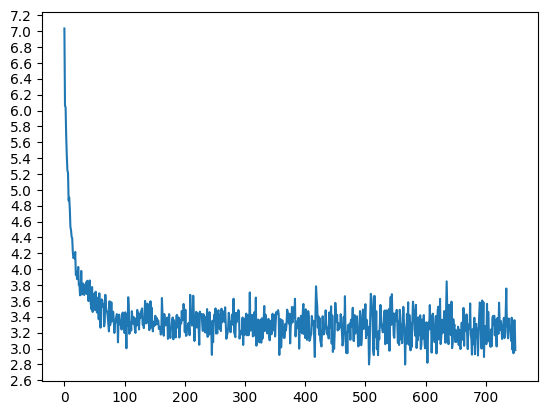

In [ ]:
hidden_size = 256
embedding_size = 300
encoder = EncoderRNN(input_lang.n_words, embedding_size, hidden_size, pretrained_embeddings=ingredient_embedding).to(device)
attn_decoder = AttnDecoderRNN(embedding_size, hidden_size, output_lang.n_words, dropout_p=0.1, pretrained_embeddings=recipe_embedding).to(device)

n_iters = 75000
print_every = 5000

trainIters_attn(encoder, attn_decoder, n_iters= n_iters, print_every=print_every)

In [ ]:
torch.save(encoder.state_dict(), 'spicy1_encoder.pth')
torch.save(attn_decoder.state_dict(), 'spicy1_decoder.pth')

In [ ]:
def beam_search_decode_pointer_generator(encoder, decoder, pair, output_lang,
                                         beam_width=3, max_length=300, ngram_size=2, length_penalty=0.7):

    # CHANGE: Prepare extended vocabulary
    pair_data = tensorsFromPair(pair)

    input_tensor = pair_data['input_tensor']
    enc_batch_extend_vocab = pair_data['enc_batch_extend_vocab']
    extra_zeros = pair_data['extra_zeros']
    input_tokens = pair[0]  # raw tokens for OOV recovery

    input_length = (input_tensor != PAD_token).sum().item()

    encoder_hidden = encoder.initHidden()
    encoder_outputs = torch.zeros(max_length, encoder.hidden_size, device=device)

    for ei in range(input_length):
        encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
        encoder_outputs[ei] = encoder_output[0, 0]

    decoder_hidden = encoder_hidden
    decoder_input = torch.tensor([[SOS_token]], device=device)

    beams = [(decoder_input, decoder_hidden, [], 0.0, False)]

    for _ in range(max_length):
        all_candidates = []

        for decoder_input, decoder_hidden, output_seq, cum_log_prob, eos_reached in beams:
            if eos_reached:
                all_candidates.append((decoder_input, decoder_hidden, output_seq, cum_log_prob, eos_reached))
                continue

            decoder_output, decoder_hidden, _ = decoder(
                decoder_input, decoder_hidden, encoder_outputs,
                enc_batch_extend_vocab=enc_batch_extend_vocab,
                extra_zeros=extra_zeros
            )

            log_probs, top_indices = torch.topk(torch.log(decoder_output + 1e-12), beam_width * 2)

            candidates = 0
            for i in range(log_probs.size(1)):
                token = top_indices[0][i].item()
                log_prob = log_probs[0][i].item()
                new_output_seq = output_seq + [token]

                # N-gram blocking
                if len(new_output_seq) >= ngram_size:
                    ngram = tuple(new_output_seq[-ngram_size:])
                    prev_ngrams = set(tuple(new_output_seq[j:j + ngram_size]) for j in range(len(new_output_seq) - ngram_size))
                    if ngram in prev_ngrams:
                        continue

                new_cum_log_prob = cum_log_prob + log_prob
                eos_hit = token == EOS_token

                all_candidates.append((
                    torch.tensor([[token]], device=device),
                    decoder_hidden,
                    new_output_seq,
                    new_cum_log_prob,
                    eos_hit
                ))

                candidates += 1
                if candidates >= beam_width:
                    break

        if not all_candidates:
            break

        beams = sorted(
            all_candidates,
            key=lambda x: x[3] / ((len(x[2]) ** length_penalty) if len(x[2]) > 0 else 1),
            reverse=True
        )[:beam_width]

        if all(b[4] for b in beams):
            break

    # Select the first completed beam or fall back to the top beam
    final_seq = next((b[2] for b in beams if b[4]), beams[0][2])

    # CHANGE: Decode using extended vocab
    decoded_words = []
    for idx in final_seq:
        if idx < output_lang.n_words:
            word = output_lang.index2word.get(idx, '<UNK>')
        else:
            oov_idx = idx - output_lang.n_words
            if oov_idx < len(pair_data.get('oov_list', [])):
                word = pair_data['oov_list'][oov_idx]
            else:
                word = '<UNK>'
        decoded_words.append(word)

    return [w for w in decoded_words if w != 'EOS']

In [ ]:
gold_texts = []
pred_texts = []
max_length = 250


for pair in test_pairs:
    with torch.no_grad():

        decoded_words = beam_search_decode_pointer_generator(encoder, attn_decoder, pair, output_lang)

        predicted_text = ' '.join(decoded_words).strip()
        gold_texts.append(pair[1].strip())
        pred_texts.append(predicted_text)



# Tokenize for BLEU
ref_tokens = [nltk.word_tokenize(text) for text in gold_texts]
hyp_tokens = [nltk.word_tokenize(text) for text in pred_texts]

# BLEU-4 with smoothing
smoothie = SmoothingFunction().method4
bleu_scores = [sentence_bleu([ref], hyp, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)
               for ref, hyp in zip(ref_tokens, hyp_tokens)]
avg_bleu = sum(bleu_scores) / len(bleu_scores)

# METEOR
meteor_scores = [meteor_score([ref], hyp) for ref, hyp in zip(ref_tokens, hyp_tokens)]
avg_meteor = sum(meteor_scores) / len(meteor_scores)

# BERTScore
P, R, F1 = score(pred_texts, gold_texts, lang='en', verbose=False)
avg_bertscore_f1 = F1.mean().item()

# Print results
print(f"BLEU-4 Score:  {avg_bleu:.4f}")
print(f"METEOR Score:  {avg_meteor:.4f}")
print(f"BERTScore F1: {avg_bertscore_f1:.4f}")

# Save to csv
df_results = pd.DataFrame({
    'Input': [' '.join(inp) for inp, _ in test_pairs],
    'Gold': gold_texts,
    'Prediction': pred_texts,
    'BLEU': bleu_scores,
    'METEOR': meteor_scores,
    'BERTScore_F1': F1.tolist()
})
df_results.to_csv('spicy1_predictions.csv', index=False)
print("Predictions saved to spicy1_predictions.csv")


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BLEU-4 Score:  0.0249
METEOR Score:  0.1462
BERTScore F1: 0.8560
Predictions saved to spicy1_predictions.csv


In [ ]:
# To perform qualitative comparison

pred_texts = []

for pair in qual_pairs:
    with torch.no_grad():

        decoded_words = beam_search_decode_pointer_generator(encoder, attn_decoder, pair, output_lang)

        # Collect results
        predicted_text = ' '.join(decoded_words).strip()
        pred_texts.append(predicted_text)
        print(pred_texts)

['combine all ingredients in a large bowl and bring to a boil .']
['combine all ingredients in a large bowl and bring to a boil .', 'beat cream cheese until fluffy . add milk and beat until smooth . fold in cool whip . pour into pie shell . chill until firm .']


#### 1.3.2 Sequence-to-Sequence model with attention
*   Builds upon Spicy 1 Model
*   Implements coverage mechanism following Kiddon et al. (2016) https://github.com/uwnlp/neural-checklist and See et al. (2017) https://github.com/atulkum/pointer_summarizer

In [ ]:
class AttnDecoderRNN(nn.Module):
    def __init__(self, embedding_size, hidden_size, output_size, dropout_p=0.1, max_length=300, pretrained_embeddings=None):
        super(AttnDecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding_size = embedding_size
        self.output_size = output_size
        self.dropout_p = dropout_p
        self.max_length = max_length

        # Load pretrained embedding if any
        if pretrained_embeddings is not None:
            self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings)
        else:
            self.embedding = nn.Embedding(self.output_size, self.embedding_size)

        self.attn = nn.Linear(self.hidden_size + self.embedding_size, self.max_length)
        self.attn_combine = nn.Linear(self.hidden_size + self.embedding_size, self.hidden_size)
        self.dropout = nn.Dropout(self.dropout_p)
        self.gru = nn.GRU(self.hidden_size, self.hidden_size)
        self.out = nn.Linear(self.hidden_size, self.output_size)

        # Pointer-generator mechanism
        self.p_gen_linear = nn.Linear(self.hidden_size * 2 + self.embedding_size, 1)

        # CHANGE: Checklist coverage
        self.checklist_linear = nn.Linear(hidden_size, 1)  # Predicts checklist updates
        self.lambda_cov = 0.1  # Weight for coverage penalty

    def forward(self, input, hidden, encoder_outputs, enc_batch_extend_vocab, extra_zeros, checklist=None):
        embedded = self.embedding(input).view(1, 1, -1)
        embedded = self.dropout(embedded)

        # Compute attention
        attn_weights = F.softmax(self.attn(torch.cat((embedded[0], hidden[0]), 1)), dim=1)

        # CHANGE: Update checklist (if provided)
        if checklist is not None:
            # Top-1 attention index
            _, top_indices = attn_weights.topk(1, dim=1)
            binary_update = torch.zeros_like(checklist) # binary tensor to mark newly covered tokens
            binary_update[0, top_indices[0]] = 1.0 # top attended token marked as 'covered'
            checklist = torch.clamp(checklist + binary_update, max=1.0) # checklist updated

        attn_applied = torch.bmm(attn_weights.unsqueeze(0), encoder_outputs.unsqueeze(0))

        # Decoder step
        output = torch.cat((embedded[0], attn_applied[0]), 1)
        output = self.attn_combine(output).unsqueeze(0)
        output = F.relu(output)
        output, hidden = self.gru(output, hidden)

        # Pointer-generator
        p_gen_input = torch.cat((attn_applied[0], hidden[0], embedded[0]), 1)
        p_gen = torch.sigmoid(self.p_gen_linear(p_gen_input))
        vocab_dist = p_gen * F.softmax(self.out(output[0]), dim=1)
        attn_dist = (1 - p_gen) * attn_weights

        if extra_zeros is not None:
            vocab_dist = torch.cat([vocab_dist, extra_zeros], 1)

        final_dist = vocab_dist.scatter_add(1, enc_batch_extend_vocab, attn_dist)

        # CHANGE: Coverage penalty (if checklist is used)
        cov_loss = 0.0
        if checklist is not None:
            cov_loss = ((1.0 - checklist) ** 2).sum()  # Penalize uncovered tokens


        return final_dist, hidden, attn_weights, cov_loss, checklist

In [ ]:
def train_attn(teacher_forcing_ratio, input_tensor, target_tensor, encoder, decoder,
               encoder_optimizer, decoder_optimizer, criterion, enc_batch_extend_vocab,
               extra_zeros, max_length=300):
    encoder_hidden = encoder.initHidden()
    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()

    input_length = (input_tensor != PAD_token).sum().item()
    target_length = (target_tensor != PAD_token).sum().item()

    encoder_outputs = torch.zeros(max_length, encoder.hidden_size, device=device)

    # Encode input
    for ei in range(input_length):
        encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
        encoder_outputs[ei] = encoder_output[0, 0]

    decoder_input = torch.tensor([[SOS_token]], device=device)
    decoder_hidden = encoder_hidden

    # CHANGE: Initialize checklist (zeros)
    checklist = torch.zeros(1, max_length, device=device)  # Tracks coverage of input tokens
    total_cov_loss = 0.0

    loss = 0
    use_teacher_forcing = random.random() < teacher_forcing_ratio

    for di in range(target_length):
        decoder_output, decoder_hidden, attn_weights, cov_loss, checklist = decoder(
            decoder_input, decoder_hidden, encoder_outputs, enc_batch_extend_vocab,
            extra_zeros, checklist)

        total_cov_loss += cov_loss
        loss += criterion(torch.log(decoder_output + 1e-12), target_tensor[di])

        if use_teacher_forcing:
            decoder_input = target_tensor[di]  # Teacher forcing
        else:
            topv, topi = decoder_output.topk(1)
            decoder_input = topi.squeeze().detach()

        if decoder_input.item() == EOS_token:
            break

    # CHANGE: Add coverage penalty to loss
    total_loss = loss + decoder.lambda_cov * total_cov_loss
    total_loss.backward()

    # Clip gradients
    torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1.0)
    torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=1.0)

    encoder_optimizer.step()
    decoder_optimizer.step()

    return total_loss.item() / target_length

In [ ]:
def evaluate_loss(encoder, decoder, val_pairs, criterion, max_length=300):
    encoder.eval()
    decoder.eval()
    total_loss = 0

    with torch.no_grad():
        for pair in val_pairs:
            pair_data = tensorsFromPair(pair)
            input_tensor = pair_data['input_tensor']
            target_tensor = pair_data['target_tensor']
            enc_batch_extend_vocab = pair_data['enc_batch_extend_vocab']
            extra_zeros = pair_data['extra_zeros']

            input_length = (input_tensor != PAD_token).sum().item()
            target_length = (target_tensor != PAD_token).sum().item()

            encoder_hidden = encoder.initHidden()
            encoder_outputs = torch.zeros(max_length, encoder.hidden_size, device=device)

            for ei in range(input_length):
                encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
                encoder_outputs[ei] = encoder_output[0, 0]

            decoder_input = torch.tensor([[SOS_token]], device=device)
            decoder_hidden = encoder_hidden
            checklist = torch.zeros(1, max_length, device=device)
            loss = 0
            total_cov_loss = 0

            for di in range(target_length):
                decoder_output, decoder_hidden, _, cov_loss, checklist = decoder(
                    decoder_input, decoder_hidden, encoder_outputs,
                    enc_batch_extend_vocab, extra_zeros, checklist)
                loss += criterion(torch.log(decoder_output + 1e-12), target_tensor[di])
                total_cov_loss += cov_loss
                topv, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze().detach()
                if decoder_input.item() == EOS_token:
                    break

            total_loss += (loss + decoder.lambda_cov * total_cov_loss).item() / target_length

    encoder.train()
    decoder.train()
    return total_loss / len(val_pairs)


In [ ]:
# To call train iteratively and periodically print the progress
# (% of examples, time so far, estimated time) and average loss.

from torch.optim.lr_scheduler import ReduceLROnPlateau

def trainIters_attn(encoder, decoder, n_iters, print_every=1000, plot_every=100, learning_rate=0.001):
    start = time.time()
    plot_losses = []
    print_loss_total = 0  # Reset every print_every
    plot_loss_total = 0  # Reset every plot_every

    encoder_optimizer = optim.Adam(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.Adam(decoder.parameters(), lr=learning_rate)

    encoder_scheduler = ReduceLROnPlateau(encoder_optimizer)
    decoder_scheduler = ReduceLROnPlateau(decoder_optimizer)


    training_pairs = [tensorsFromPair(random.choice(pairs)) for i in range(n_iters)]
    criterion = nn.NLLLoss(ignore_index=PAD_token)

    for iter in range(1, n_iters + 1):

        # Gradually decay teacher forcing; reaches 0.2 at 65000 iterations
        teacher_forcing_ratio = max(0.2, 1.0 - (iter * 0.000012))

        pair_data = training_pairs[iter - 1]
        input_tensor = pair_data['input_tensor']
        target_tensor = pair_data['target_tensor']
        enc_batch_extend_vocab = pair_data['enc_batch_extend_vocab']
        extra_zeros = pair_data['extra_zeros']

        loss = train_attn(teacher_forcing_ratio, input_tensor, target_tensor, encoder,
                     decoder, encoder_optimizer, decoder_optimizer, criterion,
                    enc_batch_extend_vocab=enc_batch_extend_vocab, extra_zeros=extra_zeros)
        print_loss_total += loss
        plot_loss_total += loss


        # Reduces learning rate if validation loss stops improving
        if iter % 500 == 0 or iter % print_every == 0:
            val_loss = evaluate_loss(encoder, decoder, val_pairs, criterion)

        if iter % 500 == 0:
            encoder_scheduler.step(val_loss)
            decoder_scheduler.step(val_loss)


        if iter % print_every == 0:
            print_loss_avg = print_loss_total / print_every
            print_loss_total = 0
            print('%s (%d %d%%) %.4f %.4f' % (timeSince(start, iter / n_iters),
                                         iter, iter / n_iters * 100, print_loss_avg, val_loss))


        if iter % plot_every == 0:
            plot_loss_avg = plot_loss_total / plot_every
            plot_losses.append(plot_loss_avg)
            plot_loss_total = 0

    showPlot(plot_losses)


    # Save plot_losses to a file
    save_losses_to_csv(plot_losses, 'losses_spicy2.csv')

12m 21s (- 173m 0s) (5000 6%) 33.0940 15.2807
23m 59s (- 155m 58s) (10000 13%) 31.2558 17.1239
35m 18s (- 141m 15s) (15000 20%) 30.2934 17.5087
46m 20s (- 127m 26s) (20000 26%) 29.1269 17.3784
57m 13s (- 114m 26s) (25000 33%) 28.3346 17.3860
67m 45s (- 101m 37s) (30000 40%) 27.5848 17.3537
77m 58s (- 89m 7s) (35000 46%) 26.5286 17.3568
87m 50s (- 76m 51s) (40000 53%) 25.5836 17.3526
97m 36s (- 65m 4s) (45000 60%) 24.6207 17.3504
107m 4s (- 53m 32s) (50000 66%) 23.7889 17.3702
116m 14s (- 42m 16s) (55000 73%) 22.6952 17.3723
125m 12s (- 31m 18s) (60000 80%) 21.8379 17.3789
133m 52s (- 20m 35s) (65000 86%) 21.0021 17.3911
142m 19s (- 10m 9s) (70000 93%) 20.2971 17.3975
150m 44s (- 0m 0s) (75000 100%) 20.0931 17.3994


<Figure size 640x480 with 0 Axes>

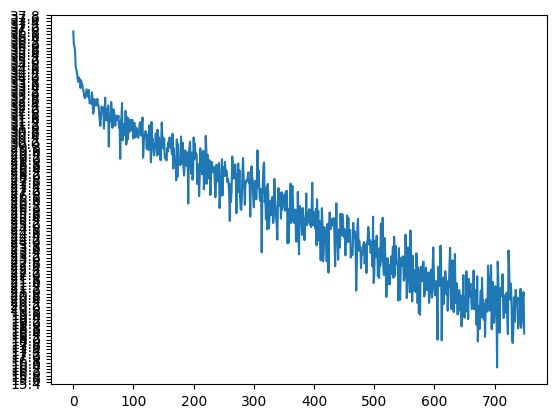

In [ ]:
hidden_size = 256
embedding_size = 300
encoder = EncoderRNN(input_lang.n_words, embedding_size, hidden_size, pretrained_embeddings=ingredient_embedding).to(device)
attn_decoder = AttnDecoderRNN(embedding_size, hidden_size, output_lang.n_words, dropout_p=0.1, pretrained_embeddings=recipe_embedding).to(device)

n_iters = 75000
print_every = 5000

trainIters_attn(encoder, attn_decoder, n_iters= n_iters, print_every=print_every)

In [ ]:
torch.save(encoder.state_dict(), 'spicy2_encoder.pth')
torch.save(attn_decoder.state_dict(), 'spicy2_decoder.pth')

In [ ]:
def beam_search_decode_coverage(encoder, decoder, pair, output_lang,
                                         beam_width=3, max_length=300, ngram_size=2, length_penalty=0.7):
    # Use your utility function to prepare tensors and extended vocab info
    pair_data = tensorsFromPair(pair)

    input_tensor = pair_data['input_tensor']
    enc_batch_extend_vocab = pair_data['enc_batch_extend_vocab']
    extra_zeros = pair_data['extra_zeros']
    input_tokens = pair[0]  # raw tokens for OOV recovery

    input_length = (input_tensor != PAD_token).sum().item()

    encoder_hidden = encoder.initHidden()
    encoder_outputs = torch.zeros(max_length, encoder.hidden_size, device=device)

    for ei in range(input_length):
        encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
        encoder_outputs[ei] = encoder_output[0, 0]

    decoder_hidden = encoder_hidden
    decoder_input = torch.tensor([[SOS_token]], device=device)

    beams = [(decoder_input, decoder_hidden, [], 0.0, False)]
    # CHANGE: Initialize checklist (zeros)
    checklist = torch.zeros(1, max_length, device=device)

    for _ in range(max_length):
        all_candidates = []

        for decoder_input, decoder_hidden, output_seq, cum_log_prob, eos_reached in beams:
            if eos_reached:
                all_candidates.append((decoder_input, decoder_hidden, output_seq, cum_log_prob, eos_reached))
                continue

            decoder_output, decoder_hidden, _, cov_loss, checklist = decoder(
                decoder_input, decoder_hidden, encoder_outputs,
                enc_batch_extend_vocab,
                extra_zeros, checklist)

            log_probs, top_indices = torch.topk(torch.log(decoder_output + 1e-12), beam_width * 2)

            candidates = 0
            for i in range(log_probs.size(1)):
                token = top_indices[0][i].item()
                log_prob = log_probs[0][i].item()
                new_output_seq = output_seq + [token]

                # N-gram blocking
                if len(new_output_seq) >= ngram_size:
                    ngram = tuple(new_output_seq[-ngram_size:])
                    prev_ngrams = set(tuple(new_output_seq[j:j + ngram_size]) for j in range(len(new_output_seq) - ngram_size))
                    if ngram in prev_ngrams:
                        continue

                new_cum_log_prob = cum_log_prob + log_prob
                eos_hit = token == EOS_token

                all_candidates.append((
                    torch.tensor([[token]], device=device),
                    decoder_hidden,
                    new_output_seq,
                    new_cum_log_prob,
                    eos_hit
                ))

                candidates += 1
                if candidates >= beam_width:
                    break

        if not all_candidates:
            break

        beams = sorted(
            all_candidates,
            key=lambda x: (x[3] - decoder.lambda_cov * F.relu(1 - checklist).sum().item()) / ((len(x[2]) ** length_penalty) if len(x[2]) > 0 else 1), # CHANGE: coverage-aware, incorporates checklist related penalty
            reverse=True
        )[:beam_width]

        if all(b[4] for b in beams):
            break

    # Pick final sequence
    final_seq = next((b[2] for b in beams if b[4]), beams[0][2])

    # Decode using extended vocab
    decoded_words = []
    for idx in final_seq:
        if idx < output_lang.n_words:
            word = output_lang.index2word.get(idx, '<UNK>')
        else:
            oov_idx = idx - output_lang.n_words
            if oov_idx < len(pair_data.get('oov_list', [])):
                word = pair_data['oov_list'][oov_idx]
            else:
                word = '<UNK>'
        decoded_words.append(word)

    return [w for w in decoded_words if w != 'EOS']

In [ ]:
gold_texts = []
pred_texts = []


for pair in test_pairs:
    with torch.no_grad():

        decoded_words = beam_search_decode_pointer_generator(encoder, attn_decoder, pair, output_lang)

        predicted_text = ' '.join(decoded_words).strip()
        gold_texts.append(pair[1].strip())
        pred_texts.append(predicted_text)



# Tokenize for BLEU
ref_tokens = [nltk.word_tokenize(text) for text in gold_texts]
hyp_tokens = [nltk.word_tokenize(text) for text in pred_texts]

# BLEU-4 with smoothing
smoothie = SmoothingFunction().method4
bleu_scores = [sentence_bleu([ref], hyp, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)
               for ref, hyp in zip(ref_tokens, hyp_tokens)]
avg_bleu = sum(bleu_scores) / len(bleu_scores)

# METEOR
meteor_scores = [meteor_score([ref], hyp) for ref, hyp in zip(ref_tokens, hyp_tokens)]
avg_meteor = sum(meteor_scores) / len(meteor_scores)

# BERTScore
P, R, F1 = score(pred_texts, gold_texts, lang='en', verbose=False)
avg_bertscore_f1 = F1.mean().item()

# Print results
print(f"BLEU-4 Score:  {avg_bleu:.4f}")
print(f"METEOR Score:  {avg_meteor:.4f}")
print(f"BERTScore F1: {avg_bertscore_f1:.4f}")

# Save to csv
df_results = pd.DataFrame({
    'Input': [' '.join(inp) for inp, _ in test_pairs],
    'Gold': gold_texts,
    'Prediction': pred_texts,
    'BLEU': bleu_scores,
    'METEOR': meteor_scores,
    'BERTScore_F1': F1.tolist()
})
df_results.to_csv('spicy2_predictions.csv', index=False)
print("Predictions saved to spicy2_predictions.csv")


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BLEU-4 Score:  0.0255
METEOR Score:  0.1461
BERTScore F1: 0.8542
Predictions saved to spicy2_predictions.csv


In [ ]:
# To perform qualitative comparison

pred_texts = []

for pair in qual_pairs:
    with torch.no_grad():

        decoded_words = beam_search_decode_coverage(encoder, attn_decoder, pair, output_lang)

        # Collect results
        predicted_text = ' '.join(decoded_words).strip()
        pred_texts.append(predicted_text)
        print(pred_texts)

['mix sugar and water in a saucepan . bring to a boil and boil for 5 minutes . remove from heat and add remaining ingredients . stir well . pour into mold and chill .']
['mix sugar and water in a saucepan . bring to a boil and boil for 5 minutes . remove from heat and add remaining ingredients . stir well . pour into mold and chill .', 'beat cream cheese until smooth . add remaining ingredients . mix well . pour into graham cracker crust . chill until firm . serve with crackers or crackers .']


### Plotting Losses

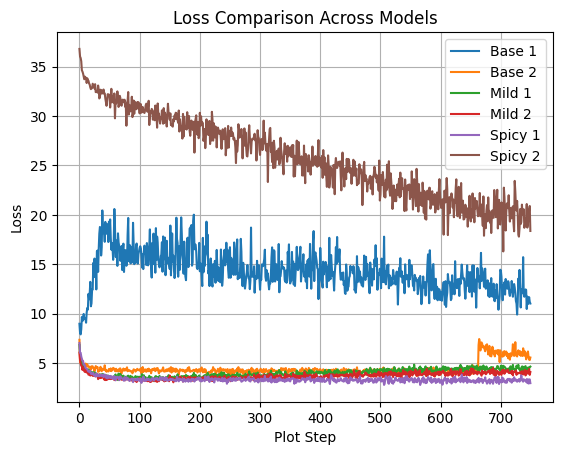

In [ ]:
import matplotlib.pyplot as plt
import csv

def load_losses_from_csv(filename):
    with open(filename, 'r') as f:
        reader = csv.reader(f)
        next(reader)  # Skip header
        return [float(row[0]) for row in reader]

losses_base1 = load_losses_from_csv('losses_base1.csv')
losses_base2 = load_losses_from_csv('losses_base2.csv')
losses_mild1 = load_losses_from_csv('losses_mild1.csv')
losses_mild2 = load_losses_from_csv('losses_mild2.csv')
losses_spicy1 = load_losses_from_csv('losses_spicy1.csv')
losses_spicy2 = load_losses_from_csv('losses_spicy2.csv')

plt.plot(losses_base1, label='Base 1')
plt.plot(losses_base2, label='Base 2')
plt.plot(losses_mild1, label='Mild 1')
plt.plot(losses_mild2, label='Mild 2')
plt.plot(losses_spicy1, label='Spicy 1')
plt.plot(losses_spicy2, label='Spicy 2')

plt.xlabel('Plot Step')
plt.ylabel('Loss')
plt.title('Loss Comparison Across Models')
plt.legend()
plt.grid(True)
plt.show()